# Setup env

In [2]:
import os
import cv2
import glob
import random
import PIL
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import montage 
import skimage.transform as skTrans
from skimage.transform import rotate
from skimage.transform import resize
from PIL import Image, ImageOps  

# neural imaging
import nilearn as nl
import nibabel as nib
import nilearn.plotting as nlplt

# PyTorch for segmentation
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import gc 
from tqdm import tqdm
import json

np.set_printoptions(precision=3, suppress=True)

# Load data
Loading all data into memory is not a good idea since the data are too big to fit in.
So we will create dataGenerators - load data on the fly as explained [here](https://stanford.edu/~shervine/blog/keras-how-to-generate-data-on-the-fly)

In [3]:
from sklearn.model_selection import train_test_split
import os

IMG_SIZE = 64

TRAIN_DATASET_PATH = '/home/nvsinh1/brats_segmentation/thesis/data/BraTS2021_Training_Data/'
train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]
train_and_val_directories = [
    d for d in train_and_val_directories
]

In [4]:
EVALUATE_DATASET_PATH = '/home/nvsinh1/brats_segmentation/thesis/experiments/data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData'
val_directories = [f.path for f in os.scandir(EVALUATE_DATASET_PATH) if f.is_dir()]
val_directories = sorted(val_directories)
def pathListIntoIds(dirList):
    return [os.path.basename(path) for path in dirList]
evaluate_ids = pathListIntoIds(val_directories)
print(f"📊 First 5 cases: {evaluate_ids[:5]}")

📊 First 5 cases: ['BraTS-GLI-00000-000', 'BraTS-GLI-00002-000', 'BraTS-GLI-00003-000', 'BraTS-GLI-00005-000', 'BraTS-GLI-00006-000']


In [5]:
EVALUATE_DATASET_1_PATH = '/home/nvsinh1/brats_segmentation/thesis/data/BraTS2024_small_dataset'
val_1_directories = [f.path for f in os.scandir(EVALUATE_DATASET_1_PATH) if f.is_dir()]
val_1_directories = sorted(val_1_directories)
def pathListIntoIds(dirList):
    return [os.path.basename(path) for path in dirList]
evaluate_1_ids = pathListIntoIds(val_1_directories)
print(f"📊 First 5 cases: {evaluate_1_ids[:5]}")

📊 First 5 cases: ['BraTS-GLI-02062-100', 'BraTS-GLI-02062-101', 'BraTS-GLI-02062-102', 'BraTS-GLI-02062-103', 'BraTS-GLI-02062-104']


In [6]:
EVALUATE_DATASET_2_PATH = '/home/nvsinh1/brats_segmentation/thesis/experiments/data/BraTS_Synthesis'
val_2_directories = [f.path for f in os.scandir(EVALUATE_DATASET_2_PATH) if f.is_dir()]
val_2_directories = sorted(val_2_directories)
def pathListIntoIds(dirList):
    return [os.path.basename(path) for path in dirList]
evaluate_2_ids = pathListIntoIds(val_2_directories)
print(f"📊 First 5 cases: {evaluate_2_ids[:5]}")

📊 First 5 cases: ['case_000000', 'case_000001', 'case_000002', 'case_000003', 'case_000004']


In [7]:
# Lấy tên case lỗi từ error log
CORRUPTED_CASE = "cache_patches_npz"  # Case đang gây lỗi

# Danh sách folder
train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]

# Lọc bỏ case lỗi
train_and_val_directories = [
    d for d in train_and_val_directories
    if not os.path.basename(d) == CORRUPTED_CASE
]

print(f"✅ Đã loại bỏ case lỗi: {CORRUPTED_CASE}")
print(f"📊 Còn lại: {len(train_and_val_directories)} cases")
def pathListIntoIds(dirList):
    return [os.path.basename(path) for path in dirList]
train_and_test_ids = pathListIntoIds(train_and_val_directories)
train_ids, test_ids = train_test_split(train_and_test_ids, test_size=0.2, random_state=42)

✅ Đã loại bỏ case lỗi: cache_patches_npz
📊 Còn lại: 1251 cases


In [8]:
train_ids_1, test_ids_1 = train_test_split(evaluate_2_ids, test_size=0.2, random_state=42)

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

def visualize_data_split(
    train_ids,
    test_ids,
    year,
    total_original=1251,
    dataset_name="BraTS",
    split_ratio="80/20",
    random_seed=42,
    stratified=True,
    figsize=(15, 7),
    dpi=300,
    save_path=None
):
    n_train = len(train_ids)
    n_test = len(test_ids)
    n_valid = n_train + n_test
    n_removed = total_original - n_valid

    if n_valid <= 0:
        raise ValueError("Training and test sets are empty.")

    train_pct = n_train / n_valid * 100
    test_pct = n_test / n_valid * 100

    # ---------- Theme ----------
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 15,
        "axes.labelsize": 12
    })

    # Thesis-friendly palette
    c_bg = "#FAFAFA"
    c_train = "#4C78A8"
    c_test = "#E45756"
    c_valid = "#72B7B2"
    c_original = "#DCEAF7"
    c_text = "#1F2937"
    c_muted = "#6B7280"
    c_border = "#D1D5DB"
    c_note = "#FFF7E6"

    fig = plt.figure(figsize=figsize, dpi=dpi, facecolor="white")
    gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1], wspace=0.18)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    for ax in (ax1, ax2):
        ax.set_facecolor(c_bg)

    # ---------- LEFT: Workflow diagram ----------
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.axis("off")

    title = f"{dataset_name} {year} Dataset Split Strategy"
    ax1.text(
        5, 9.65, title,
        ha="center", va="top",
        fontsize=17, fontweight="bold", color=c_text
    )
    ax1.text(
        5, 9.15,
        "Quality-controlled cohort preparation and reproducible train-test partitioning",
        ha="center", va="top",
        fontsize=10.5, color=c_muted
    )

    def rounded_box(ax, x, y, w, h, facecolor, edgecolor, text, text_color=c_text,
                    fontsize=11.5, lw=1.5, rounding=0.08):
        patch = FancyBboxPatch(
            (x, y), w, h,
            boxstyle=f"round,pad=0.02,rounding_size={rounding}",
            linewidth=lw,
            edgecolor=edgecolor,
            facecolor=facecolor
        )
        patch.set_path_effects([
            pe.SimplePatchShadow(offset=(1.5, -1.5), alpha=0.12),
            pe.Normal()
        ])
        ax.add_patch(patch)
        ax.text(
            x + w / 2, y + h / 2, text,
            ha="center", va="center",
            fontsize=fontsize, fontweight="semibold", color=text_color
        )

    # Original dataset
    rounded_box(
        ax1, 1.1, 7.3, 7.8, 1.25,
        facecolor=c_original, edgecolor="#9DBBD9",
        text=f"{dataset_name} {year} Original Dataset\n{total_original:,} patients"
    )

    # QC arrow + label
    ax1.annotate(
        "", xy=(5, 6.65), xytext=(5, 7.25),
        arrowprops=dict(arrowstyle="-|>", lw=1.8, color=c_muted)
    )
    ax1.text(
        5.25, 6.93, "Quality control",
        fontsize=10, color=c_muted, style="italic", ha="left"
    )

    # Valid dataset
    valid_text = f"Valid Dataset After QC\n{n_valid:,} patients"
    if n_removed > 0:
        valid_text += f"  |  Removed: {n_removed:,}"
    rounded_box(
        ax1, 1.1, 5.15, 7.8, 1.15,
        facecolor="#E8F5F2", edgecolor="#8CC7BE",
        text=valid_text
    )

    # Split arrow + label
    ax1.annotate(
        "", xy=(5, 4.45), xytext=(5, 5.1),
        arrowprops=dict(arrowstyle="-|>", lw=1.8, color=c_muted)
    )
    split_label = f"train_test_split ({split_ratio}, seed={random_seed})"
    if stratified:
        split_label += "\nstratified by class"
    ax1.text(
        5.3, 4.7, split_label,
        fontsize=9.8, color=c_muted, style="italic", ha="left", va="center"
    )

    # Train and test boxes
    rounded_box(
        ax1, 0.8, 2.45, 4.0, 1.45,
        facecolor="#EAF1F8", edgecolor=c_train,
        text=f"Training Set\n{n_train:,} patients ({train_pct:.1f}%)",
        text_color=c_train,
        fontsize=11.5,
        lw=1.8
    )

    rounded_box(
        ax1, 5.2, 2.45, 4.0, 1.45,
        facecolor="#FDEDEC", edgecolor=c_test,
        text=f"Test Set\n{n_test:,} patients ({test_pct:.1f}%)",
        text_color=c_test,
        fontsize=11.5,
        lw=1.8
    )

    ax1.text(
        2.8, 1.95,
        "Model development\nand hyperparameter tuning",
        ha="center", va="top",
        fontsize=9.5, color=c_train
    )
    ax1.text(
        7.2, 1.95,
        "Final unbiased\nperformance evaluation",
        ha="center", va="top",
        fontsize=9.5, color=c_test
    )

    principles = (
        "Design principles\n"
        "• Fixed random seed for reproducibility\n"
        "• Stratified split to preserve class distribution\n"
        "• Strict separation between training and test sets\n"
        "• No data leakage during model development"
    )

    ax1.text(
        5, 0.9, principles,
        ha="center", va="top", fontsize=9.4, color=c_text,
        bbox=dict(
            boxstyle="round,pad=0.45,rounding_size=0.08",
            facecolor=c_note, edgecolor="#E8D8A8", linewidth=1.0
        )
    )

    # ---------- RIGHT: Clean proportional chart ----------
    ax2.set_title("Post-QC Data Distribution", pad=14, fontweight="bold", color=c_text)

    # Single stacked bar
    ax2.barh(["Dataset split"], [n_train], color=c_train, edgecolor="white", height=0.55)
    ax2.barh(["Dataset split"], [n_test], left=[n_train], color=c_test, edgecolor="white", height=0.55)

    # Internal labels
    if n_train > 0:
        ax2.text(
            n_train / 2, 0,
            f"Train\n{n_train:,}\n({train_pct:.1f}%)",
            ha="center", va="center",
            color="white", fontsize=11, fontweight="bold"
        )
    if n_test > 0:
        ax2.text(
            n_train + n_test / 2, 0,
            f"Test\n{n_test:,}\n({test_pct:.1f}%)",
            ha="center", va="center",
            color="white", fontsize=11, fontweight="bold"
        )

    ax2.set_xlim(0, n_valid * 1.08)
    ax2.set_xlabel("Number of patients", fontweight="bold", color=c_text)
    ax2.tick_params(axis="x", colors=c_muted)
    ax2.tick_params(axis="y", colors=c_text)
    ax2.grid(axis="x", linestyle="--", alpha=0.25)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["bottom"].set_color(c_border)

    summary_text = (
        f"Original cohort: {total_original:,}\n"
        f"Valid after QC: {n_valid:,}\n"
        f"Excluded: {max(n_removed, 0):,}"
    )
    ax2.text(
        0.98, 0.18, summary_text,
        transform=ax2.transAxes,
        ha="right", va="bottom",
        fontsize=10, color=c_text,
        bbox=dict(
            boxstyle="round,pad=0.4,rounding_size=0.08",
            facecolor="white", edgecolor=c_border
        )
    )

    # ---------- Global layout ----------
    fig.suptitle(
        f"{dataset_name} {year}: Cohort Refinement and Train-Test Partition",
        y=0.98, fontsize=18, fontweight="bold", color=c_text
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")

    return fig

/tmp/ipykernel_110423/3744335254.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


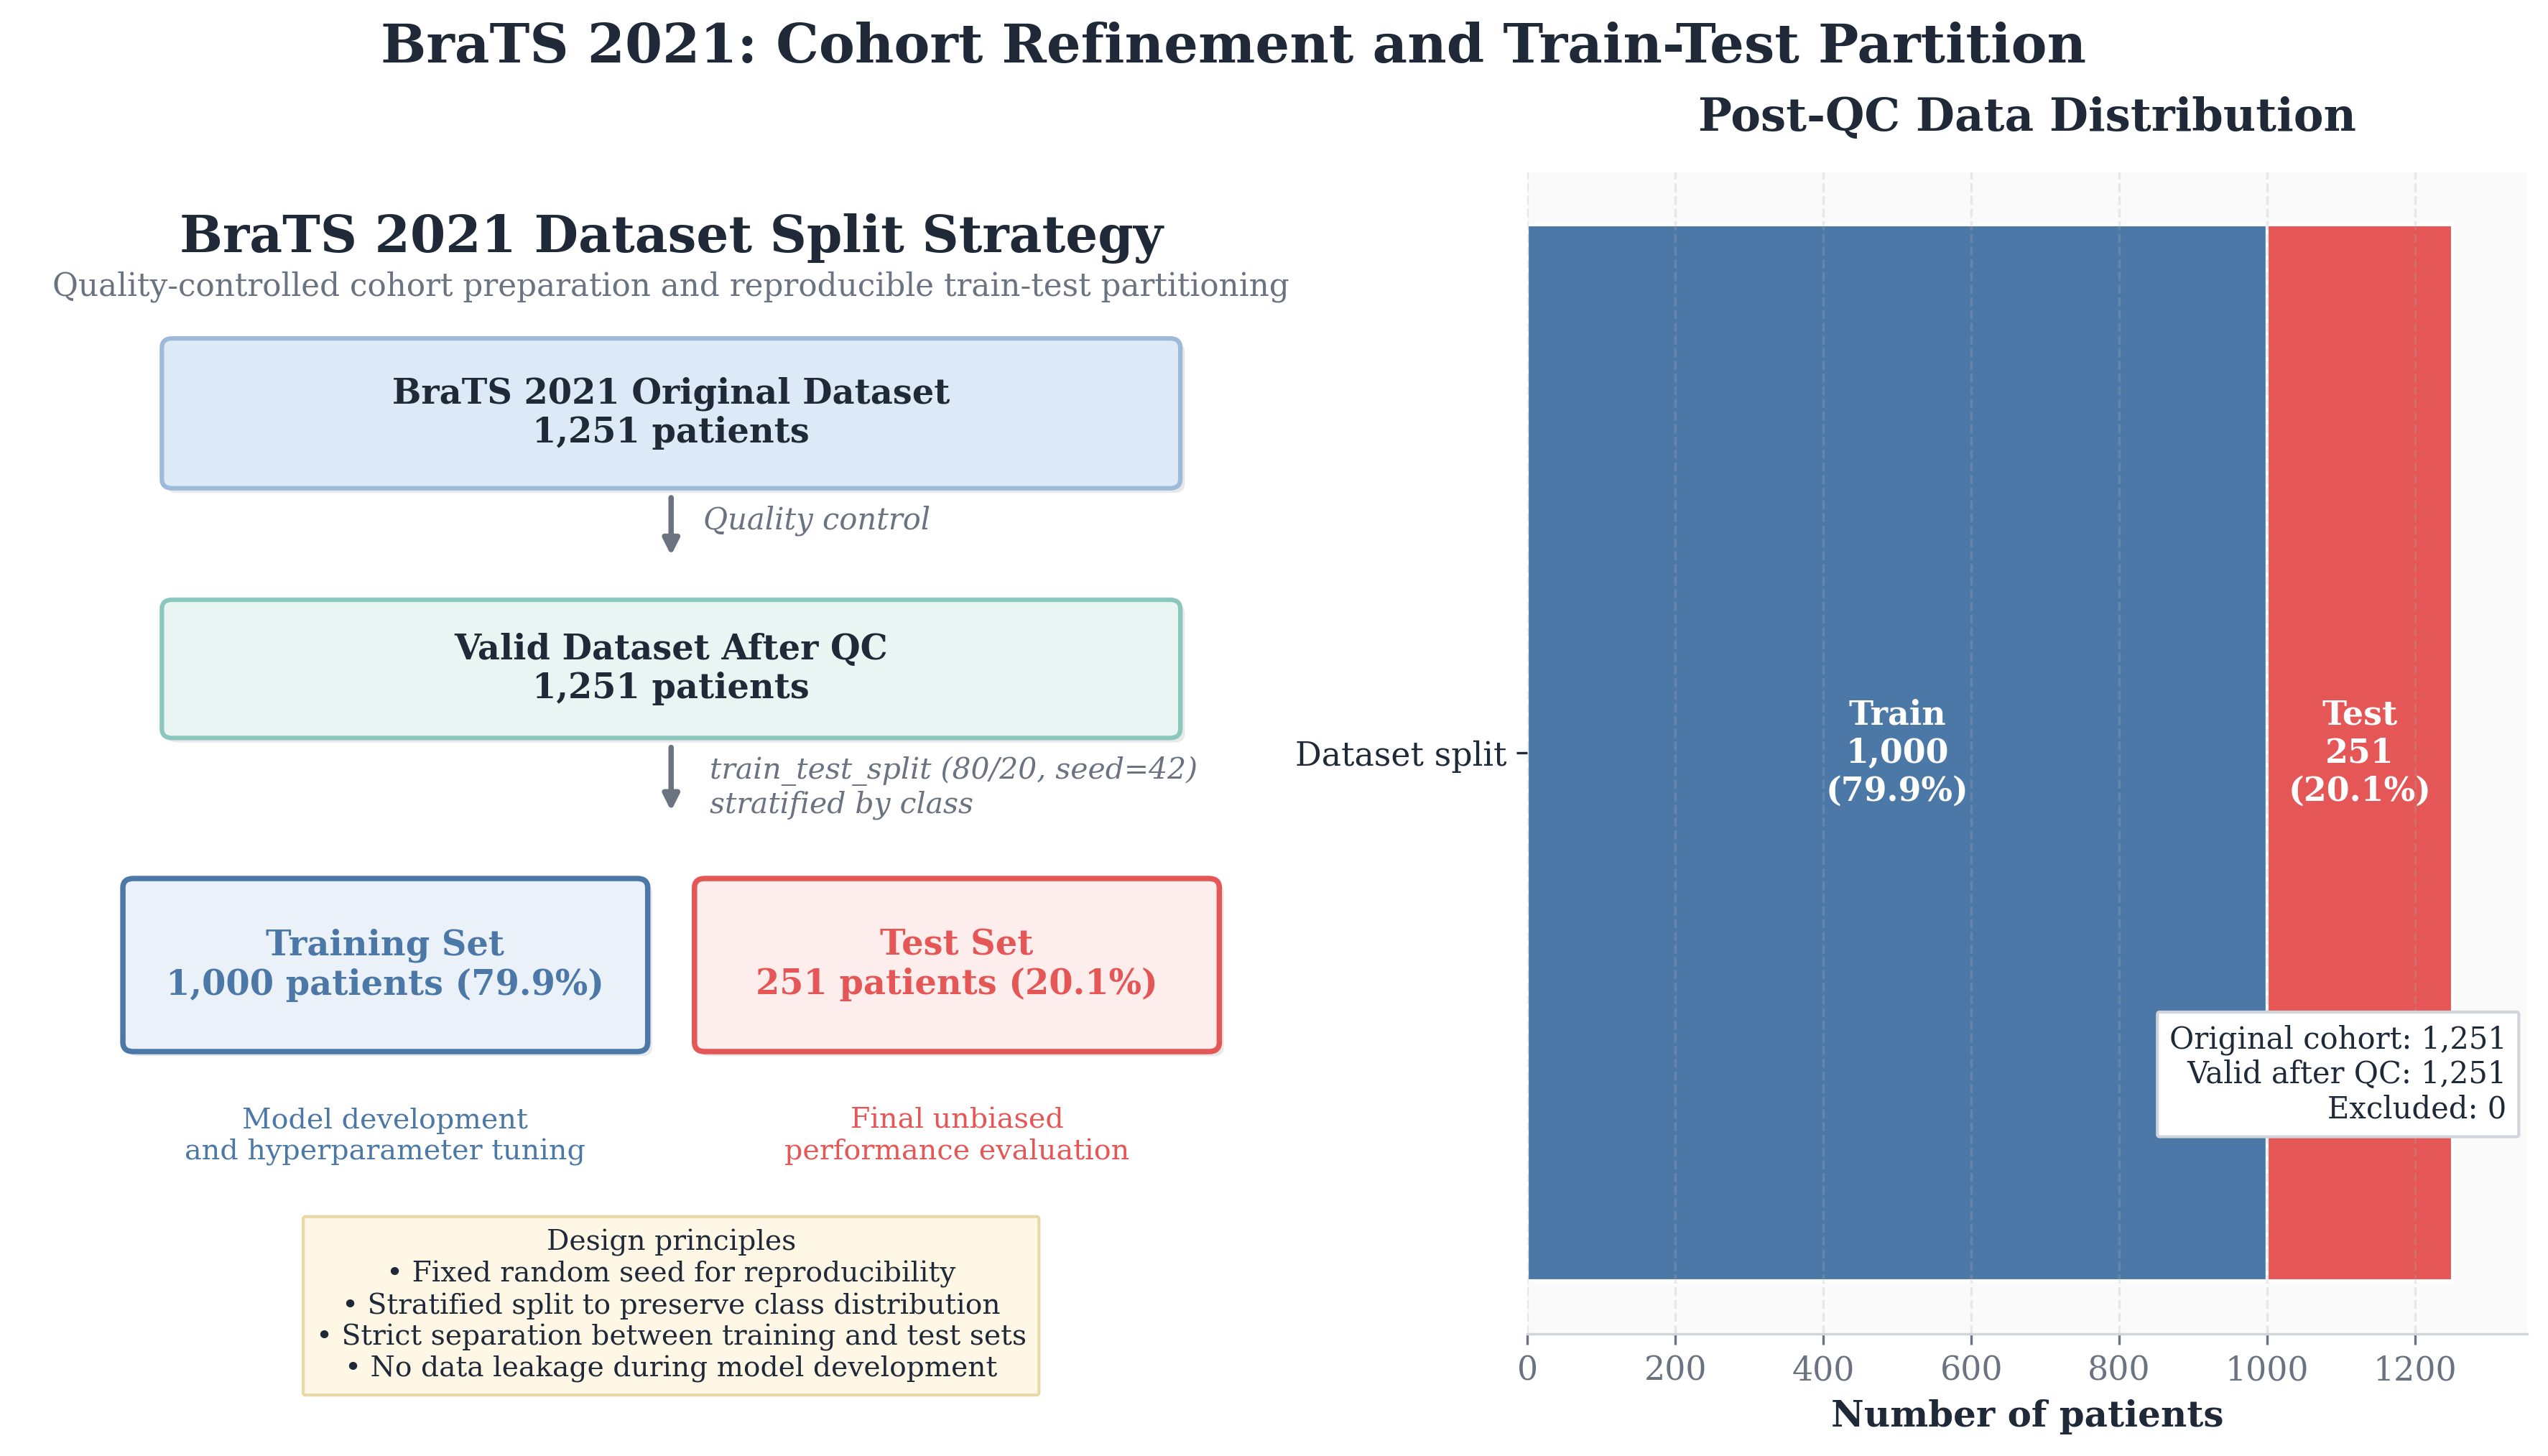

BRATS 2021 DATASET SPLIT SUMMARY
Original dataset size:        369 patients
Removed (corrupted cases):    -882 patients
Valid dataset size:           1251 patients

Training set:                 1000 patients (79.94%)
Test set:                     251 patients (20.06%)

Split ratio:                  1000/251 ≈ 80/20
Random seed:                  42 (for reproducibility)


In [10]:
fig = visualize_data_split(
    train_ids=train_ids,
    test_ids=test_ids,
    year=2021,
    total_original=1251,
    dataset_name="BraTS",
    save_path="dataset_split_brats_2021.png"
)
plt.show()

# Print detailed statistics
print("BRATS 2021 DATASET SPLIT SUMMARY")
print(f"Original dataset size:        {369} patients")
print(f"Removed (corrupted cases):    {369 - (len(train_ids) + len(test_ids))} patients")
print(f"Valid dataset size:           {len(train_ids) + len(test_ids)} patients")
print(f"\nTraining set:                 {len(train_ids)} patients ({len(train_ids)/(len(train_ids)+len(test_ids))*100:.2f}%)")
print(f"Test set:                     {len(test_ids)} patients ({len(test_ids)/(len(train_ids)+len(test_ids))*100:.2f}%)")
print(f"\nSplit ratio:                  {len(train_ids)}/{len(test_ids)} ≈ 80/20")
print(f"Random seed:                  42 (for reproducibility)")

/tmp/ipykernel_110423/3744335254.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


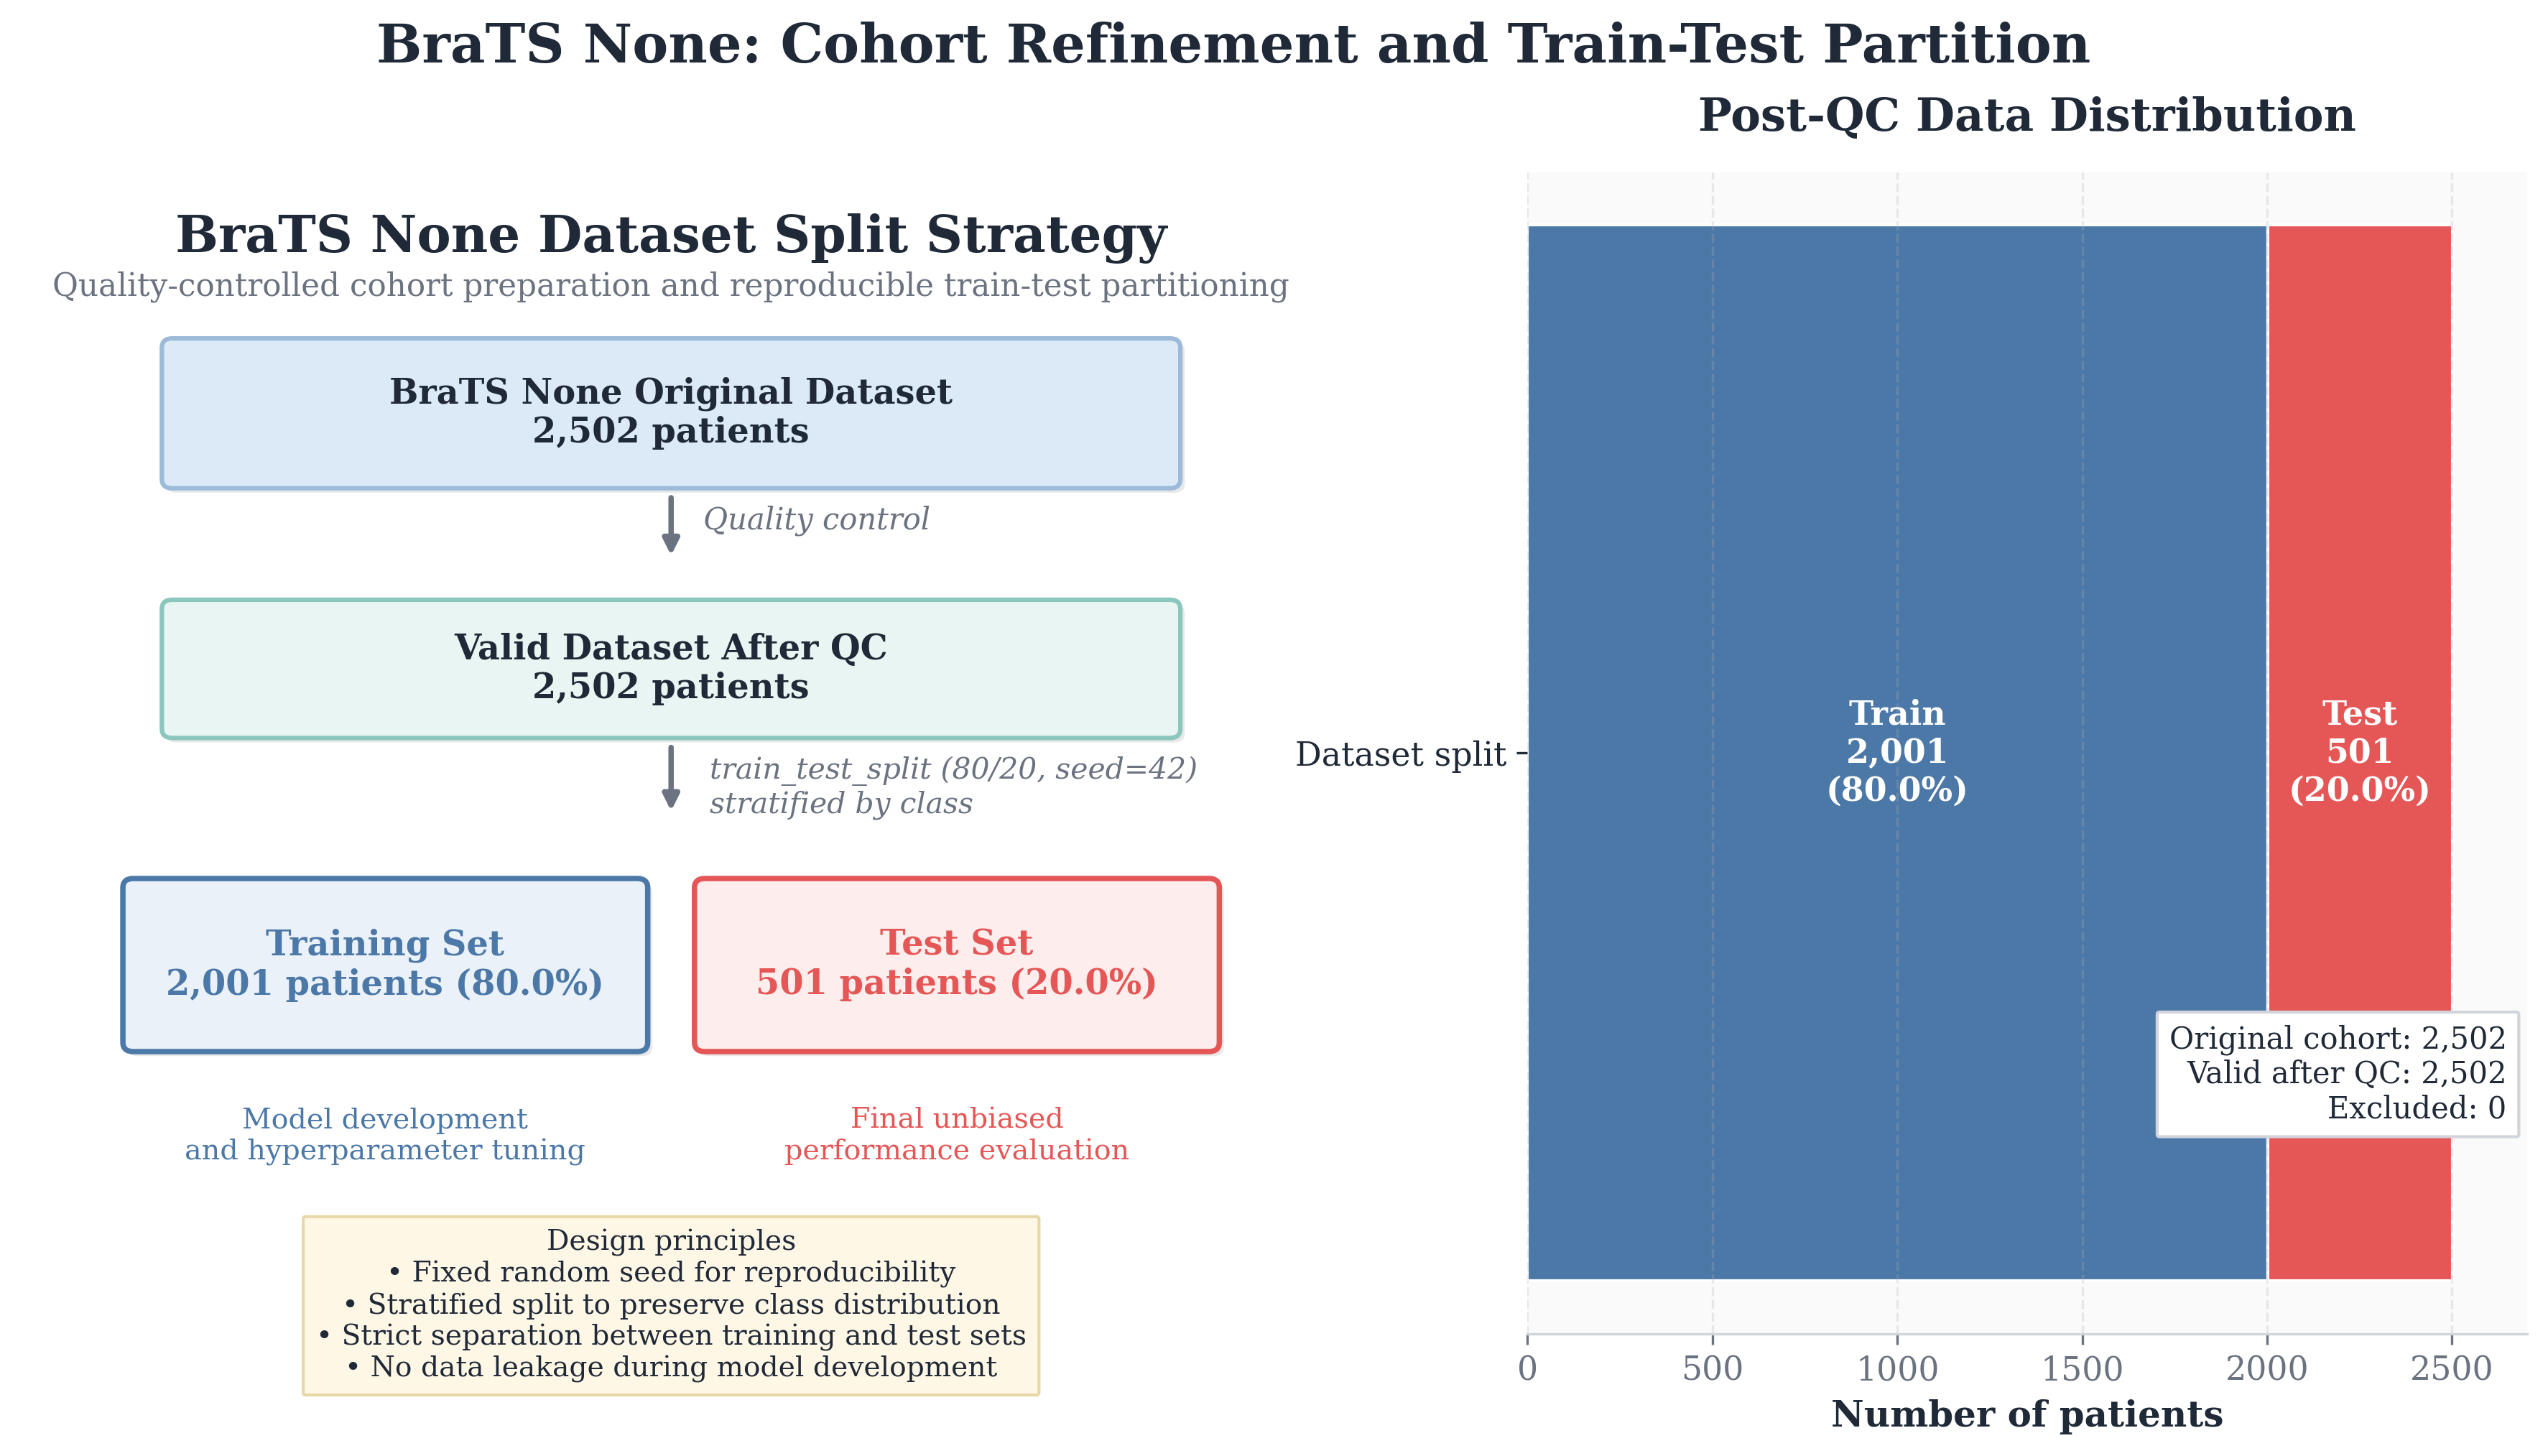

In [11]:
fig = visualize_data_split(
    train_ids=train_ids_1,
    test_ids=test_ids_1,
    year=None,
    total_original=2502,
    dataset_name="BraTS",
    save_path="dataset_split_brats_syn.png"
)
plt.show()

#

# Data Augmentation

In [12]:
import tempfile
import hashlib
import time

In [13]:
%pip install monai


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
from monai.transforms import (
    Compose, RandFlipd, RandAffined, RandGaussianNoised
)

def augment(volume, mask):
    # BEFORE: volume (H,W,D,C), mask (H,W,D)
    # Convert to MONAI expected format
    volume = np.transpose(volume, (3, 0, 1, 2))  # (C, H, W, D)
    mask = np.expand_dims(mask, axis=0)         # (1, H, W, D)

    data = {"image": volume, "label": mask}

    train_aug = Compose([
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[0, 1, 2]),
        RandAffined(
            keys=["image", "label"],
            prob=0.3,
            rotate_range=(0.1, 0.1, 0.1),
            scale_range=(0.1, 0.1, 0.1),
            mode=("bilinear", "nearest")   # image = bilinear, mask = nearest
        ),
        RandGaussianNoised(keys=["image"], prob=0.2, std=0.01),
    ])

    data = train_aug(data)

    # Convert back to (H,W,D,C) and (H,W,D)
    volume = np.transpose(data["image"], (1, 2, 3, 0))  # (H,W,D,C)
    mask = data["label"][0]                             # (H,W,D)

    return volume, mask

<frozen importlib._bootstrap_external>:1297: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [15]:
def adaptive_threshold_per_modality(vol, lower_percentile=0.5, upper_percentile=99.9):
    for c in range(vol.shape[-1]):
        img = vol[..., c]
        if img.max() > 0:
            nonzero = img[img > 0]
            if len(nonzero) > 10:  # Đảm bảo có đủ samples
                lower = np.percentile(nonzero, lower_percentile)
                upper = np.percentile(nonzero, upper_percentile)
                img = np.clip(img, lower, upper)
                vol[..., c] = img
    return vol

def fixed_threshold_per_modality(vol, threshold_dict=None):
    if threshold_dict is None:
        # ✅ Giảm threshold xuống để không mất thông tin
        threshold_dict = {
            0: 0.5,   # FLAIR - giảm từ 2
            1: 0.2,   # T1 - giảm từ 1
            2: 0.8,   # T1CE - giảm từ 3
            3: 0.5    # T2 - giảm từ 2
        }
    for c in range(vol.shape[-1]):
        thresh = threshold_dict.get(c, 0)
        vol[..., c][vol[..., c] < thresh] = 0
    return vol

In [16]:
from torch.utils.data import Dataset
import numpy as np
import random
import torch
import os
import nibabel as nib

In [17]:
class PatchDataGenerator(Dataset):
    def __init__(self, list_IDs, dataset_root, patch_size=(64,64,64), patches_per_volume=20, n_channels=4, n_classes=4, shuffle=True, augmentation=None, use_threshold=True, threshold_method='adaptive', tumor_sampling_strategy='balanced', min_tumor_ratio=0.01):
        self.list_IDs = list_IDs
        self.dataset_root = dataset_root
        self.patch_size = np.array(patch_size)
        self.patches_per_volume = patches_per_volume
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.augmentation = augmentation
        self.use_threshold = use_threshold
        self.threshold_method = threshold_method
        self.tumor_sampling_strategy = tumor_sampling_strategy
        self.min_tumor_ratio = min_tumor_ratio
        
        self.patch_indices = [(case, i) for case in self.list_IDs for i in range(self.patches_per_volume)]
        if self.shuffle:
            random.shuffle(self.patch_indices)

    def __len__(self):
        return len(self.patch_indices)

    def __getitem__(self, index):
        case_id, _ = self.patch_indices[index]
        vol, seg = self._load_volume(case_id)
        if vol is None:
            # skip corrupted case → return next valid sample
            return self.__getitem__((index + 1) % len(self.patch_indices))
        if self.use_threshold:
            vol = self._thresholding_per_modality(vol)
        vol = self._normalize_per_modality(vol)
        
        target = self._decide_patch_target()
        for attempt in range(12):
            if target == 'tumor_focus':
                vol_patch, seg_patch = self._get_tumor_center_crop(vol, seg)
            else:
                vol_patch, seg_patch = self._random_crop_3d(vol, seg)
            
            tumor_ratio = np.mean(seg_patch > 0)
            if target != 'tumor_focus' or tumor_ratio >= self.min_tumor_ratio:
                break
        
        if self.augmentation is not None:
            vol_patch, seg_patch = self.augmentation(vol_patch, seg_patch)
            if isinstance(vol_patch, torch.Tensor): 
                vol_patch = vol_patch.cpu().numpy()
            if isinstance(seg_patch, torch.Tensor): 
                seg_patch = seg_patch.cpu().numpy()
        
        X = torch.from_numpy(vol_patch).permute(3,0,1,2).float()
        y = torch.from_numpy(seg_patch).long()
        
        return X, y

    def _load_volume(self, case_id):
        try:
            case_dir = os.path.join(self.dataset_root, case_id)
            vols = []
            for mod in ['flair','t1','t1ce','t2']:
                path = os.path.join(case_dir, f"{case_id}_{mod}.nii.gz")
                if not os.path.exists(path):
                    print(f"[WARN] Missing file: {path} → skipping")
                    return None, None

                img = nib.load(path).get_fdata(dtype=np.float32)
                vols.append(img)

            seg_path = os.path.join(case_dir, f"{case_id}_seg.nii.gz")
            if not os.path.exists(seg_path):
                print(f"[WARN] Missing segmentation: {seg_path} → skipping")
                return None, None

            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            seg[seg == 4] = 3

            vol = np.stack(vols, axis=-1)
            return vol, seg

        except Exception as e:
            print(f"[ERROR] Failed loading case {case_id}: {e}")
            return None, None


    def _thresholding_per_modality(self, vol):
        if self.threshold_method == 'adaptive':
            return adaptive_threshold_per_modality(vol, lower_percentile=0.5, upper_percentile=99.9)
        return fixed_threshold_per_modality(vol)

    def _normalize_per_modality(self, vol):
        for c in range(vol.shape[-1]):
            img = vol[..., c]
            mask = img > 0
            if mask.any():
                m, s = img[mask].mean(), img[mask].std()
                if s > 1e-7:
                    vol[..., c][mask] = (img[mask] - m) / s
                else:
                    vol[..., c][mask] = img[mask] - m
        return vol

    def _get_tumor_center_crop(self, vol, seg):
        tumor_mask = seg > 0
        if not tumor_mask.any():
            return self._random_crop_3d(vol, seg)
        coords = np.where(tumor_mask)
        center = np.array([(c.min()+c.max())//2 for c in coords])
        size = self.patch_size
        start = np.clip(center - size//2, 0, np.array(vol.shape[:3]) - size)
        jitter = np.random.randint(-size//6, size//6+1, size=3)
        start = np.clip(start + jitter, 0, np.array(vol.shape[:3]) - size)
        end = start + size
        return vol[start[0]:end[0], start[1]:end[1], start[2]:end[2], :], seg[start[0]:end[0], start[1]:end[1], start[2]:end[2]]

    def _random_crop_3d(self, vol, seg):
        H, W, D = vol.shape[:3]
        ph, pw, pd = self.patch_size
        h = random.randint(0, H-ph)
        w = random.randint(0, W-pw)
        d = random.randint(0, D-pd)
        return vol[h:h+ph, w:w+pw, d:d+pd, :], seg[h:h+ph, w:w+pw, d:d+pd]

    def _decide_patch_target(self):
        if self.tumor_sampling_strategy == 'random':
            return 'any'
        if self.tumor_sampling_strategy == 'tumor_focus':
            return 'tumor_focus' if random.random() < 0.8 else 'any'
        if self.tumor_sampling_strategy == 'balanced':
            r = random.random()
            return 'tumor_focus' if r < 0.4 else 'any'
        return 'any'

In [18]:
class VolumeDataGenerator(torch.utils.data.Dataset):
    def __init__(self, list_IDs, dataset_root, n_channels=4, n_classes=4, use_threshold=True, threshold_method='adaptive'):
        self.list_IDs = list_IDs
        self.dataset_root = dataset_root
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.use_threshold = use_threshold
        self.threshold_method = threshold_method

    def __len__(self):
        return len(self.list_IDs)

    def __getitem__(self, idx):
        case_id = self.list_IDs[idx]

        vol, seg = self._load_volume(case_id)
        if vol is None:
            # skip corrupted → try next
            return self.__getitem__((idx + 1) % len(self.list_IDs))

        # SAME preprocessing as train
        if self.use_threshold:
            vol = self._thresholding_per_modality(vol)

        vol = self._normalize_per_modality(vol)

        # (H,W,D,C) → (C,H,W,D)
        X = torch.from_numpy(vol).permute(3, 0, 1, 2).float()
        y = torch.from_numpy(seg).long()

        return X, y, case_id
    
    def _load_volume(self, case_id):
        try:
            case_dir = os.path.join(self.dataset_root, case_id)
            vols = []
            for mod in ['flair','t1','t1ce','t2']:
                path = os.path.join(case_dir, f"{case_id}_{mod}.nii.gz")
                if not os.path.exists(path):
                    print(f"[WARN] Missing file: {path}")
                    return None, None

                img = nib.load(path).get_fdata(dtype=np.float32)
                vols.append(img)

            seg_path = os.path.join(case_dir, f"{case_id}_seg.nii.gz")
            if not os.path.exists(seg_path):
                print(f"[WARN] Missing segmentation: {seg_path}")
                return None, None

            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            seg[seg == 4] = 3

            vol = np.stack(vols, axis=-1)  # (H,W,D,C)
            return vol, seg

        except Exception as e:
            print(f"[ERROR] Failed loading case {case_id}: {e}")
            return None, None


    def _thresholding_per_modality(self, vol):
        if self.threshold_method == 'adaptive':
            return adaptive_threshold_per_modality(
                vol, lower_percentile=0.5, upper_percentile=99.9
            )
        return fixed_threshold_per_modality(vol)


    def _normalize_per_modality(self, vol):
        for c in range(vol.shape[-1]):
            img = vol[..., c]
            mask = img > 0
            if mask.any():
                m, s = img[mask].mean(), img[mask].std()
                if s > 1e-7:
                    vol[..., c][mask] = (img[mask] - m) / s
                else:
                    vol[..., c][mask] = img[mask] - m
        return vol

In [19]:
class VolumeDataGeneratorEval(torch.utils.data.Dataset):
    def __init__(self, list_IDs, dataset_root, n_channels=4, n_classes=4, use_threshold=True, threshold_method='adaptive'):
        self.list_IDs = list_IDs
        self.dataset_root = dataset_root
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.use_threshold = use_threshold
        self.threshold_method = threshold_method

    def __len__(self):
        return len(self.list_IDs)

    def __getitem__(self, idx):
        case_id = self.list_IDs[idx]

        vol, seg = self._load_volume(case_id)
        if vol is None:
            return self.__getitem__((idx + 1) % len(self.list_IDs))
        
        if self.use_threshold:
            vol = self._thresholding_per_modality(vol)

        vol = self._normalize_per_modality(vol)

        # (H,W,D,C) → (C,H,W,D)
        X = torch.from_numpy(vol).permute(3, 0, 1, 2).float()
        y = torch.from_numpy(seg).long()

        return X, y, case_id
    
    def _load_volume(self, case_id):
        try:
            case_dir = os.path.join(self.dataset_root, case_id)
            modality_map = {
                't2f': 't2f',
                't1n': 't1n',
                't1c': 't1c',
                't2w': 't2w'
            }
            vols = []
            for mod in modality_map.values():
                path = os.path.join(
                    case_dir,
                    f"{case_id}-{mod}.nii.gz"
                )
                if not os.path.exists(path):
                    print(f"[WARN] Missing file: {path}")
                    return None, None

                img = nib.load(path).get_fdata(dtype=np.float32)
                vols.append(img)

            seg_path = os.path.join(
                case_dir,
                f"{case_id}-seg.nii.gz"
            )
            if not os.path.exists(seg_path):
                print(f"[WARN] Missing segmentation: {seg_path}")
                return None, None
            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            seg[seg == 4] = 3  
            vol = np.stack(vols, axis=-1)  # (H, W, D, C)
            return vol, seg
        except Exception as e:
            print(f"[ERROR] Failed loading case {case_id}: {e}")
            return None, None

    def _thresholding_per_modality(self, vol):
        if self.threshold_method == 'adaptive':
            return adaptive_threshold_per_modality(
                vol, lower_percentile=0.5, upper_percentile=99.9
            )
        return fixed_threshold_per_modality(vol)


    def _normalize_per_modality(self, vol):
        for c in range(vol.shape[-1]):
            img = vol[..., c]
            mask = img > 0
            if mask.any():
                m, s = img[mask].mean(), img[mask].std()
                if s > 1e-7:
                    vol[..., c][mask] = (img[mask] - m) / s
                else:
                    vol[..., c][mask] = img[mask] - m
        return vol

In [20]:
training_generator = PatchDataGenerator(
    list_IDs=train_ids,
    dataset_root=TRAIN_DATASET_PATH,
    patch_size=(64, 64, 64),
    patches_per_volume=6,
    n_channels=4,
    n_classes=4,
    shuffle=True,
    augmentation=augment,
    use_threshold=True,
    tumor_sampling_strategy='tumor_focus',
    min_tumor_ratio=0.01
)
training_loader = DataLoader(
    training_generator,
    batch_size=6,
    shuffle=False,           # patch_indices đã shuffle
    num_workers=6,           # parallel loading
    pin_memory=True,
    drop_last=True,
    persistent_workers=True
)

In [21]:
test_dataset = VolumeDataGenerator(
    list_IDs=test_ids,
    dataset_root=TRAIN_DATASET_PATH,
    use_threshold=True,
    threshold_method='adaptive'
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,   
    shuffle=False,
    num_workers=1,
    pin_memory=True
)

In [22]:
from torch.utils.data import Dataset, DataLoader
from monai.transforms import (
    Compose,
    RandFlipd,
    RandAffined,
    RandGaussianNoised,
    ResizeWithPadOrCropd,
)

MODALITIES = ["t1", "t1ce", "t2", "flair"]

class BraTSDataset(Dataset):
    def __init__(
        self,
        dataset_root,
        cases,
        augmentation=False,
        use_threshold=True,
        threshold_method="adaptive",
        spatial_size=(128, 128, 128),
        include_seg=False,
    ):
        self.dataset_root = dataset_root
        self.cases = cases
        self.use_threshold = use_threshold
        self.threshold_method = threshold_method
        self.augmentation = augmentation
        self.spatial_size = spatial_size
        self.include_seg = include_seg

        resize_keys = ["image"] + (["label"] if include_seg else [])
        self.resize = ResizeWithPadOrCropd(
            keys=resize_keys,
            spatial_size=self.spatial_size,
        )

        if augmentation:
            aug_keys = ["image"] + (["label"] if include_seg else [])
            self.aug = Compose([
                RandFlipd(keys=aug_keys, prob=0.5, spatial_axis=[0, 1, 2]),
                RandAffined(
                    keys=aug_keys,
                    prob=0.3,
                    rotate_range=(0.1, 0.1, 0.1),
                    scale_range=(0.1, 0.1, 0.1),
                    mode=("bilinear", "nearest") if include_seg else "bilinear",
                ),
                RandGaussianNoised(keys=["image"], prob=0.2, std=0.01),
            ])
        else:
            self.aug = None

    def __len__(self):
        return len(self.cases)

    def _load_volume(self, case_id):
        case_dir = os.path.join(self.dataset_root, case_id)
        vols = []

        for mod in MODALITIES:
            path = os.path.join(case_dir, f"{mod}.nii.gz")
            if not os.path.exists(path):
                print(f"[WARN] Missing {mod} in {case_id}")
                return None, None
            try:
                img = nib.load(path).get_fdata(dtype=np.float32)
            except Exception as e:
                print(f"[ERROR] Cannot load {path}: {e}")
                return None, None
            vols.append(img)

        vol = np.stack(vols, axis=-1)  # (H, W, D, C)

        seg = None
        if self.include_seg:
            seg_path = os.path.join(case_dir, "seg.nii.gz")
            if os.path.exists(seg_path):
                seg = nib.load(seg_path).get_fdata().astype(np.uint8)
                seg[seg == 4] = 3
            else:
                print(f"[WARN] Missing seg in {case_id}")
                return None, None

        return vol, seg

    def _adaptive_threshold(self, vol, lower=0.5, upper=99.9):
        for c in range(vol.shape[-1]):
            img = vol[..., c]
            mask = img > 0
            if mask.any():
                lo = np.percentile(img[mask], lower)
                hi = np.percentile(img[mask], upper)
                vol[..., c] = np.clip(img, lo, hi)
        return vol

    def _normalize_per_modality(self, vol):
        for c in range(vol.shape[-1]):
            img = vol[..., c]
            mask = img > 0
            if mask.any():
                m = img[mask].mean()
                s = img[mask].std()
                if s > 1e-6:
                    vol[..., c][mask] = (img[mask] - m) / s
                else:
                    vol[..., c][mask] = img[mask] - m
        return vol

    def __getitem__(self, index):
        case_id = self.cases[index]
        vol, seg = self._load_volume(case_id)

        if vol is None:
            return self.__getitem__((index + 1) % len(self))

        if self.use_threshold and self.threshold_method == "adaptive":
            vol = self._adaptive_threshold(vol)
        vol = self._normalize_per_modality(vol)

        # image -> channel first
        image = np.transpose(vol, (3, 0, 1, 2)).astype(np.float32)   # (4, H, W, D)

        data = {"image": image}

        if self.include_seg and seg is not None:
            # IMPORTANT: add channel dim for MONAI
            label = seg[np.newaxis, ...].astype(np.uint8)            # (1, H, W, D)
            data["label"] = label

        data = self.resize(data)

        if self.aug is not None:
            data = self.aug(data)

        image = data["image"]
        if isinstance(image, np.ndarray):
            image = torch.from_numpy(image)
        image = image.float()

        output = {
            "image": image,
            "domain_id": torch.tensor(0, dtype=torch.long),
            "case_id": case_id,
        }

        if self.include_seg and "label" in data:
            label = data["label"]
            if isinstance(label, np.ndarray):
                label = torch.from_numpy(label)

            # remove channel dim: (1,H,W,D) -> (H,W,D)
            if label.ndim == 4 and label.shape[0] == 1:
                label = label.squeeze(0)

            output["label"] = label.long()

        return output

def split_cases(dataset_root, split_ratio=0.8, seed=42):
    cases = sorted([
        d for d in os.listdir(dataset_root)
        if d.startswith("case_") and os.path.isdir(os.path.join(dataset_root, d))
    ])
    random.seed(seed)
    random.shuffle(cases)
    split_idx = int(len(cases) * split_ratio)
    train_cases = cases[:split_idx]
    test_cases = cases[split_idx:]
    return train_cases, test_cases

In [23]:
dataset_root = "/home/nvsinh1/brats_segmentation/thesis/experiments/data/BraTS_Synthesis"
train_cases, test_cases = split_cases(
    dataset_root=dataset_root,
    split_ratio=0.8,
    seed=42,
)
train_syn_dataset = BraTSDataset(
    dataset_root=dataset_root,
    cases=train_cases,
    augmentation=False,
    use_threshold=True,
    threshold_method="adaptive",
    spatial_size=(128, 128, 128),
    include_seg=True,
)
test_syn_dataset = BraTSDataset(
    dataset_root=dataset_root,
    cases=test_cases,
    augmentation=False,
    use_threshold=True,
    threshold_method="adaptive",
    spatial_size=(128, 128, 128),
    include_seg=True,
)
train_syn_loader = DataLoader(
    train_syn_dataset,
    batch_size=3,
    shuffle=True,
    num_workers=3,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
    prefetch_factor=1,
)
test_syn_loader = DataLoader(
    test_syn_dataset,
    batch_size=3,
    shuffle=False,
    num_workers=3,
    pin_memory=True,
    drop_last=False,
    persistent_workers=True,
    prefetch_factor=1,
)

In [24]:
evaluate_dataset = VolumeDataGeneratorEval(
    list_IDs=evaluate_ids,
    dataset_root=EVALUATE_DATASET_PATH,
    use_threshold=True,
    threshold_method='adaptive'
)
evaluate_loader = DataLoader(
    evaluate_dataset,
    batch_size=1,   
    shuffle=False,
    num_workers=1,
    pin_memory=True
) 

In [25]:
evaluate_dataset_1 = VolumeDataGeneratorEval(
    list_IDs=evaluate_1_ids,
    dataset_root=EVALUATE_DATASET_1_PATH,
    use_threshold=True,
    threshold_method='adaptive'
)
evaluate_loader_1 = DataLoader(
    evaluate_dataset_1,
    batch_size=1,   
    shuffle=False,
    num_workers=1,
    pin_memory=True
) 

In [26]:
import os
import numpy as np


def get_case_ids(dataset_root, exclude_case_ids=None, sort_ids=True):
    """
    Get case folder names from dataset root.
    Works for formats such as:
    - BraTS2021_xxx
    - BraTS-GLI-xxxxx
    - case_000000
    """
    exclude_case_ids = set(exclude_case_ids or [])

    case_ids = []
    for f in os.scandir(dataset_root):
        if f.is_dir():
            case_id = os.path.basename(f.path)
            if case_id not in exclude_case_ids:
                case_ids.append(case_id)

    if sort_ids:
        case_ids = sorted(case_ids)

    return case_ids


def resolve_case_filepaths(case_id, dataset_root, modality="t1ce"):
    """
    Resolve modality and segmentation file paths across multiple BraTS-style formats.

    Supported examples
    ------------------
    1) 2021 style:
       case_id/case_id_t1ce.nii.gz
       case_id/case_id_seg.nii.gz

    2) 2023/2024 BraTS-GLI style:
       case_id/case_id-t1c.nii
       case_id/case_id-seg.nii

    3) Synthesys / simplified folder style:
       case_000000/t1ce.nii.gz
       case_000000/seg.nii.gz
    """
    case_dir = os.path.join(dataset_root, case_id)
    if not os.path.isdir(case_dir):
        raise FileNotFoundError(
            f"Case directory not found: {case_dir}\n"
            f"Check whether case_id matches an actual folder name in dataset_root."
        )

    modality = modality.lower()

    modality_aliases = {
        "t1c": ["t1c", "t1ce"],
        "t1ce": ["t1ce", "t1c"],
        "t1": ["t1"],
        "t2": ["t2"],
        "flair": ["flair"],
    }
    modality_candidates = modality_aliases.get(modality, [modality])

    modality_patterns = []
    seg_patterns = []

    for m in modality_candidates:
        modality_patterns.extend([
            # 2021 style
            os.path.join(case_dir, f"{case_id}_{m}.nii.gz"),
            os.path.join(case_dir, f"{case_id}_{m}.nii"),

            # 2023/2024 BraTS-GLI style
            os.path.join(case_dir, f"{case_id}-{m}.nii.gz"),
            os.path.join(case_dir, f"{case_id}-{m}.nii"),

            # Synthesys style
            os.path.join(case_dir, f"{m}.nii.gz"),
            os.path.join(case_dir, f"{m}.nii"),
        ])

    seg_patterns.extend([
        # 2021 style
        os.path.join(case_dir, f"{case_id}_seg.nii.gz"),
        os.path.join(case_dir, f"{case_id}_seg.nii"),

        # 2023/2024 BraTS-GLI style
        os.path.join(case_dir, f"{case_id}-seg.nii.gz"),
        os.path.join(case_dir, f"{case_id}-seg.nii"),

        # Synthesys style
        os.path.join(case_dir, "seg.nii.gz"),
        os.path.join(case_dir, "seg.nii"),
    ])

    modality_path = next((p for p in modality_patterns if os.path.exists(p)), None)
    seg_path = next((p for p in seg_patterns if os.path.exists(p)), None)

    if modality_path is None:
        available_files = sorted(os.listdir(case_dir))
        raise FileNotFoundError(
            f"Modality file not found for case '{case_id}' with modality '{modality}'.\n"
            f"Searched patterns:\n" + "\n".join(modality_patterns) +
            f"\nAvailable files in case folder:\n" + "\n".join(available_files)
        )

    if seg_path is None:
        available_files = sorted(os.listdir(case_dir))
        raise FileNotFoundError(
            f"Segmentation file not found for case '{case_id}'.\n"
            f"Searched patterns:\n" + "\n".join(seg_patterns) +
            f"\nAvailable files in case folder:\n" + "\n".join(available_files)
        )

    return modality_path, seg_path

In [27]:
def zscore_normalize_nonzero(volume, eps=1e-8):
    volume = volume.astype(np.float32)

    mask = volume > 0
    if not np.any(mask):
        return volume

    mean = volume[mask].mean()
    std = volume[mask].std()

    volume_norm = volume.copy()
    volume_norm[mask] = (volume[mask] - mean) / (std + eps)

    return volume_norm

def choose_representative_slice(seg, fallback_volume=None):
    # count tumor pixels per slice
    tumor_counts = seg.sum(axis=(0, 1))

    if tumor_counts.max() > 0:
        # slice with largest tumor region
        return int(np.argmax(tumor_counts))

    # fallback if segmentation empty
    if fallback_volume is not None:
        intensity_per_slice = fallback_volume.mean(axis=(0, 1))
        return int(np.argmax(intensity_per_slice))

    # default center slice
    return seg.shape[2] // 2

def visualize_preprocessing_stages(
    case_id,
    dataset_root,
    year=None,
    modality="t1ce",
    percentile_low=0.5,
    percentile_high=99.9,
    slice_idx=None,
    figsize=(16, 9),
    dpi=300,
    save_path=None
):
    modality_path, seg_path = resolve_case_filepaths(case_id, dataset_root, modality=modality)
    vol_original = nib.load(modality_path).get_fdata(dtype=np.float32)
    seg = nib.load(seg_path).get_fdata().astype(np.uint8)

    vol_stage1 = vol_original.copy()

    vol_stage2 = np.expand_dims(vol_stage1.copy(), axis=-1)
    vol_stage2 = adaptive_threshold_per_modality(vol_stage2, percentile_low, percentile_high)
    vol_stage2 = vol_stage2[..., 0]

    vol_stage3 = zscore_normalize_nonzero(vol_stage2)

    if slice_idx is None:
        slice_idx = choose_representative_slice(seg, fallback_volume=vol_stage1)

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11
    })

    c_text = "#1F2937"
    c_muted = "#6B7280"
    c_grid = "#D1D5DB"
    c_hist = "#4C78A8"
    c_box = "#FFF7E6"

    fig, axes = plt.subplots(
        2, 3,
        figsize=figsize,
        dpi=dpi,
        gridspec_kw={"height_ratios": [1.15, 0.85]}
    )
    fig.patch.set_facecolor("white")

    stages = [
        (vol_stage1, "Original"),
        (vol_stage2, "After Thresholding"),
        (vol_stage3, "After Normalization")
    ]

    for i, (vol, stage_title) in enumerate(stages):
        slice_data = vol[:, :, slice_idx]

        ax_img = axes[0, i]

        nonzero = slice_data[slice_data > 0]
        if nonzero.size > 0:
            vmin = np.percentile(nonzero, 1)
            vmax = np.percentile(nonzero, 99)
            if np.isclose(vmin, vmax):
                vmin, vmax = slice_data.min(), slice_data.max()
        else:
            vmin, vmax = slice_data.min(), slice_data.max()

        im = ax_img.imshow(slice_data, cmap="gray", vmin=vmin, vmax=vmax)
        ax_img.set_title(
            f"{stage_title}\n{modality.upper()} slice {slice_idx}",
            fontweight="bold",
            color=c_text,
            pad=10
        )
        ax_img.axis("off")

        cbar = fig.colorbar(im, ax=ax_img, fraction=0.045, pad=0.02)
        cbar.ax.tick_params(labelsize=9, colors=c_muted)

        ax_hist = axes[1, i]
        brain_voxels = slice_data[slice_data > 0]

        if brain_voxels.size > 0:
            ax_hist.hist(
                brain_voxels,
                bins=50,
                color=c_hist,
                alpha=0.82,
                edgecolor="white",
                linewidth=0.5
            )

            mean_val = brain_voxels.mean()
            std_val = brain_voxels.std()
            median_val = np.median(brain_voxels)

            ax_hist.axvline(mean_val, linestyle="--", linewidth=1.6, color="#E45756", label="Mean")
            ax_hist.axvline(median_val, linestyle=":", linewidth=1.6, color="#54A24B", label="Median")

            ax_hist.set_title("Intensity Distribution (non-zero voxels)", fontsize=10.5, color=c_text)
            ax_hist.set_xlabel("Intensity value", fontweight="bold", color=c_text)
            ax_hist.set_ylabel("Frequency", fontweight="bold", color=c_text)
            ax_hist.grid(alpha=0.25, linestyle="--", color=c_grid)
            ax_hist.spines["top"].set_visible(False)
            ax_hist.spines["right"].set_visible(False)

            stats_text = (
                f"μ = {mean_val:.2f}\n"
                f"σ = {std_val:.2f}\n"
                f"Median = {median_val:.2f}\n"
                f"n = {brain_voxels.size:,}"
            )

            ax_hist.text(
                0.98, 0.96, stats_text,
                transform=ax_hist.transAxes,
                ha="right", va="top",
                fontsize=9.5, color=c_text,
                bbox=dict(
                    boxstyle="round,pad=0.35,rounding_size=0.06",
                    facecolor=c_box, edgecolor="#E8D8A8"
                )
            )

            ax_hist.legend(frameon=False, fontsize=9, loc="upper left")
        else:
            ax_hist.text(
                0.5, 0.5, "No non-zero voxels",
                ha="center", va="center",
                transform=ax_hist.transAxes,
                fontsize=11, color=c_muted
            )
            ax_hist.set_axis_off()

    year_text = f"BraTS {year}" if year is not None else "BraTS Dataset"
    fig.suptitle(
        f"{year_text} Preprocessing Pipeline for Case {case_id}",
        fontsize=16,
        fontweight="bold",
        color=c_text,
        y=0.98
    )

    fig.text(
        0.5, 0.945,
        "Illustration of intensity preprocessing from raw MRI to thresholded and normalized data",
        ha="center", fontsize=10.5, color=c_muted
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")

    return fig

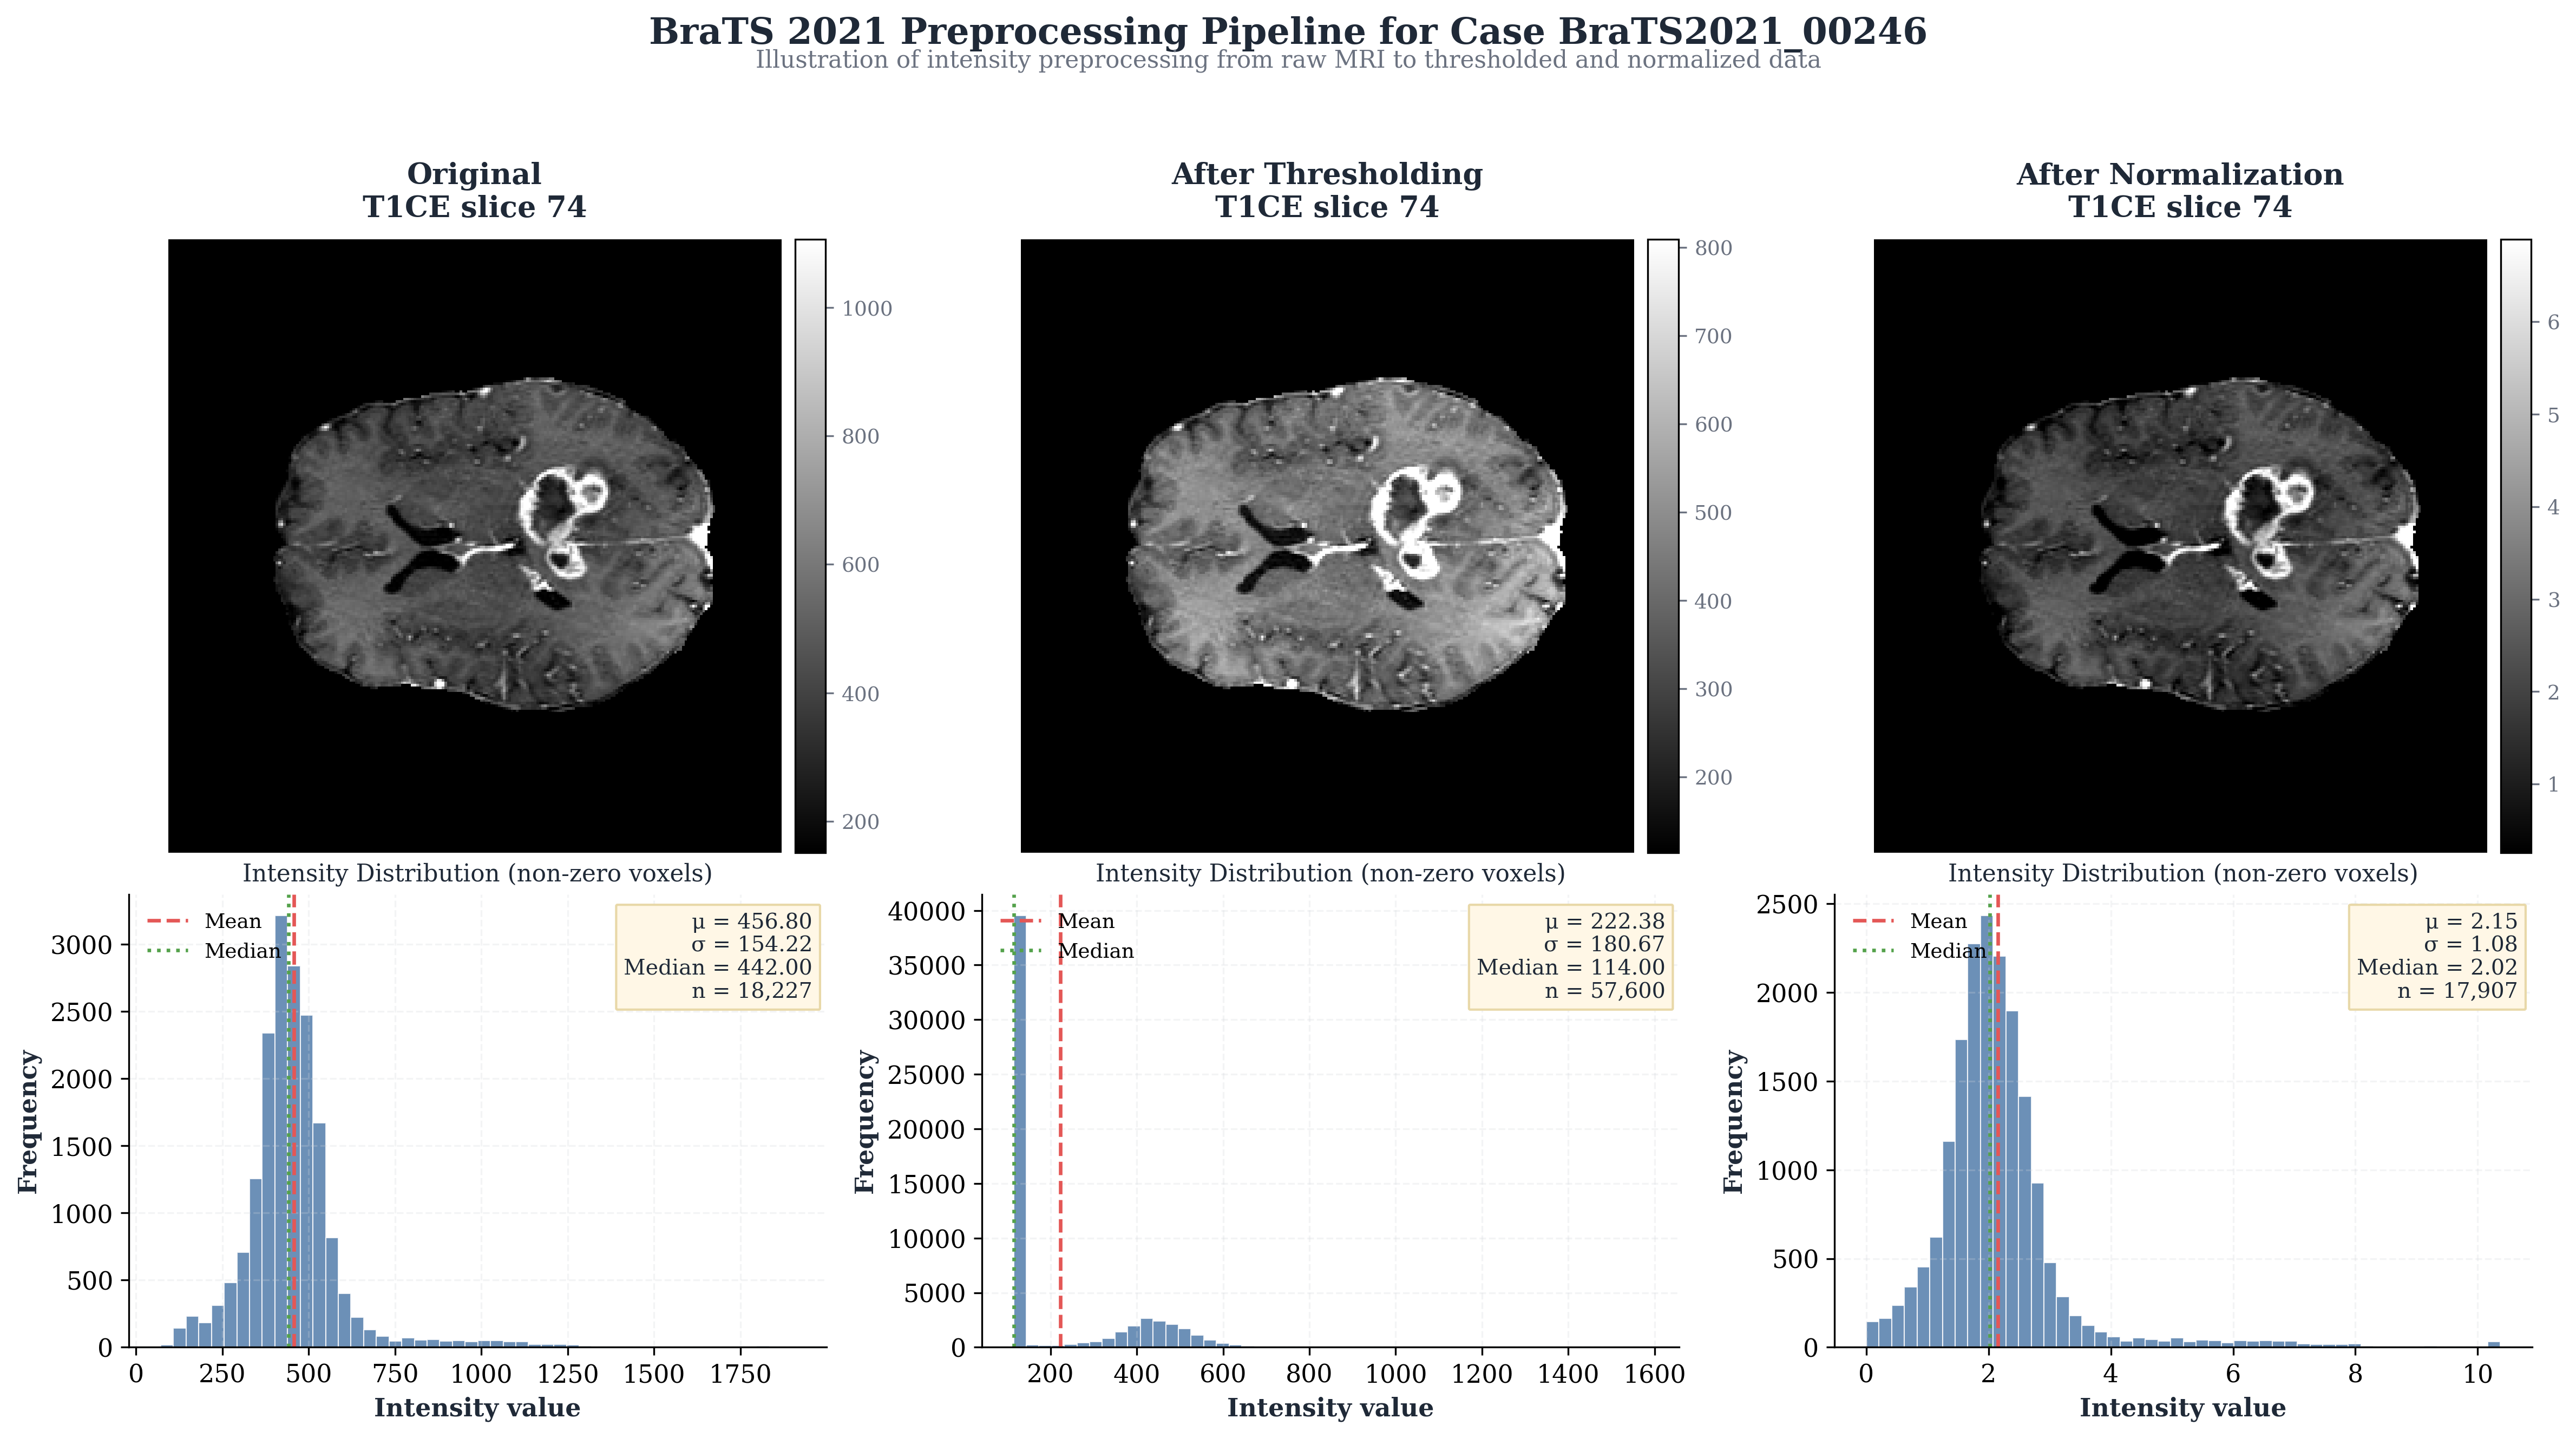

In [63]:
fig = visualize_preprocessing_stages(
    case_id=train_ids[0],
    dataset_root=TRAIN_DATASET_PATH,
    year=2021,
    modality="t1ce",
    save_path="preprocessing_stages_brats2021.png"
)
plt.show()

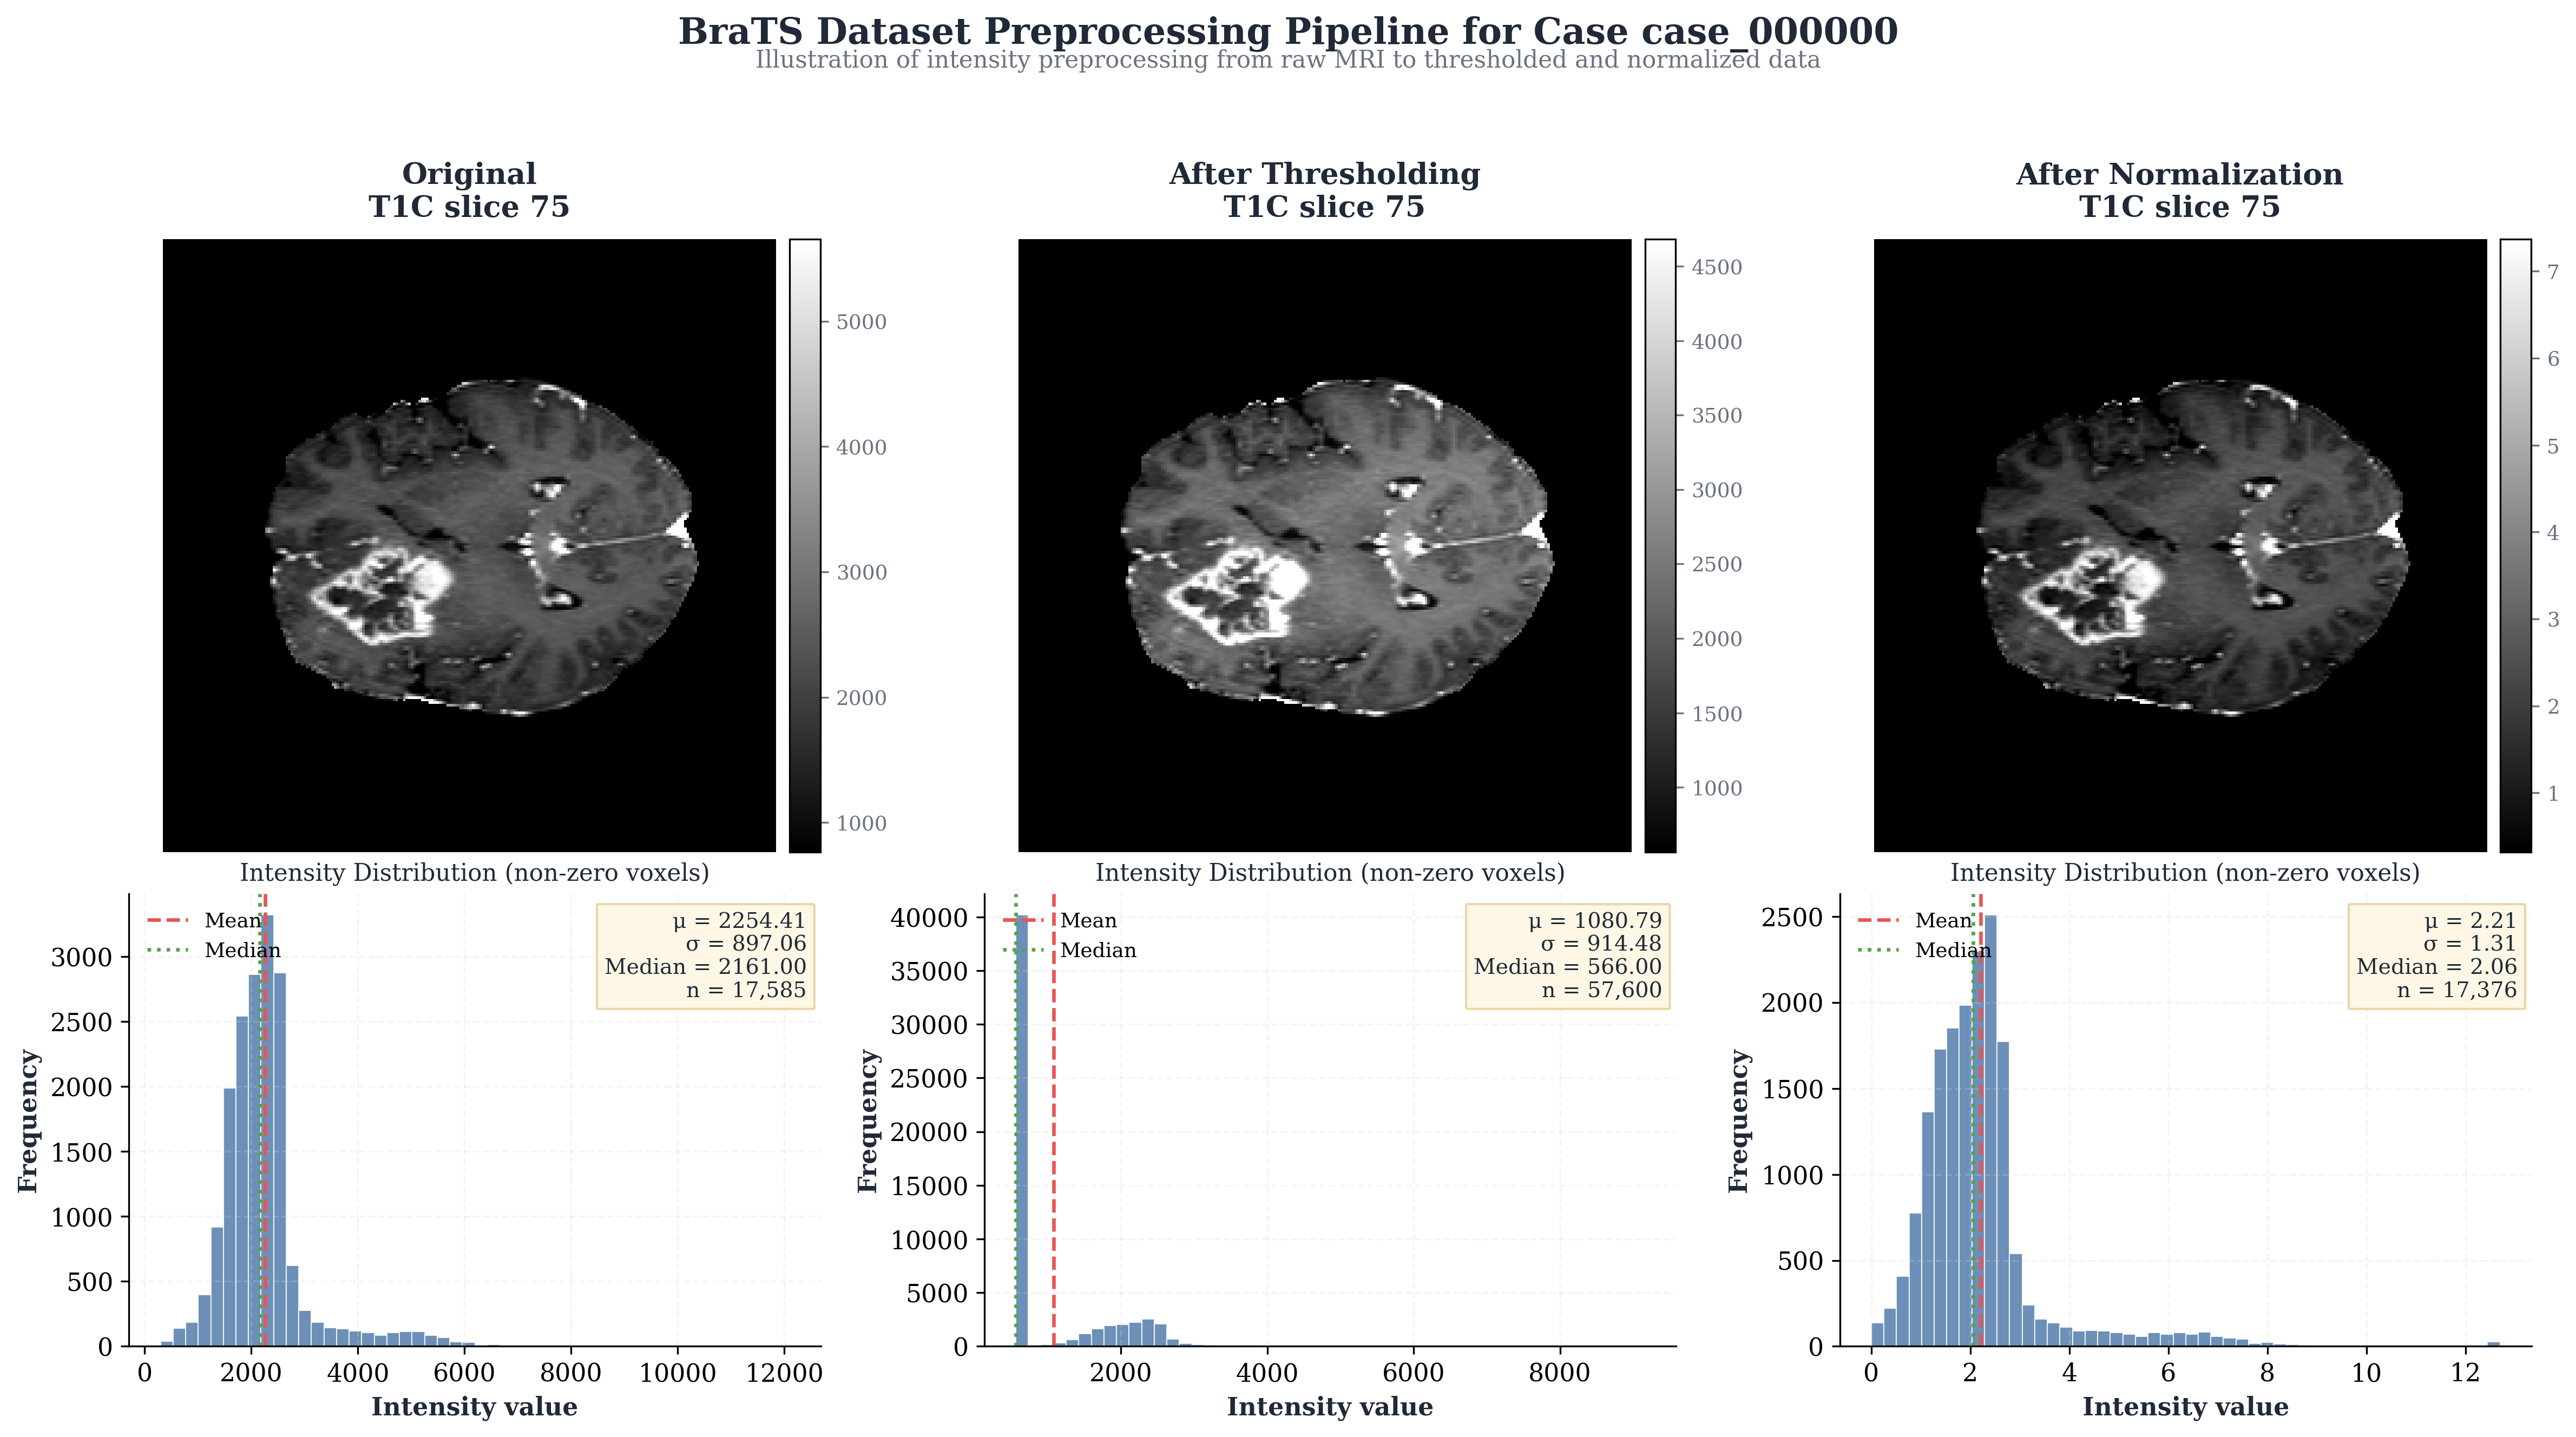

In [39]:
fig = visualize_preprocessing_stages(
    case_id=evaluate_2_ids[0],
    dataset_root=EVALUATE_DATASET_2_PATH,
    year=None,
    modality="t1c",
    save_path="preprocessing_stages_bratsbratst_synthesis.png"
)
plt.show()

In [28]:
def plot_augmentation_statistics(
    generator,
    num_samples=100,
    bins=30,
    figsize=(15, 10),
    dpi=300,
    save_path=None,
    title_prefix="Augmentation Statistical Analysis"
):
    print(f"🔍 Analyzing augmentation statistics on {num_samples} samples...")
    if len(generator) == 0:
        raise ValueError("Generator is empty.")
    original_means = []
    augmented_means = []
    original_stds = []
    augmented_stds = []
    original_aug = generator.augmentation
    try:
        for i in range(num_samples):
            idx = i % len(generator)

            # Original
            generator.augmentation = None
            X_orig, _ = generator[idx]
            X_orig_np = X_orig.numpy() if hasattr(X_orig, "numpy") else np.asarray(X_orig)
            original_means.append(float(np.mean(X_orig_np)))
            original_stds.append(float(np.std(X_orig_np)))

            # Augmented
            generator.augmentation = original_aug
            X_aug, _ = generator[idx]
            X_aug_np = X_aug.numpy() if hasattr(X_aug, "numpy") else np.asarray(X_aug)
            augmented_means.append(float(np.mean(X_aug_np)))
            augmented_stds.append(float(np.std(X_aug_np)))

    finally:
        generator.augmentation = original_aug

    original_means = np.array(original_means, dtype=np.float64)
    augmented_means = np.array(augmented_means, dtype=np.float64)
    original_stds = np.array(original_stds, dtype=np.float64)
    augmented_stds = np.array(augmented_stds, dtype=np.float64)

    # ---------- Metrics ----------
    inter_var_orig = float(np.var(original_means))
    inter_var_aug = float(np.var(augmented_means))
    intra_std_orig = float(np.mean(original_stds))
    intra_std_aug = float(np.mean(augmented_stds))

    diversity_increase = inter_var_aug / inter_var_orig if inter_var_orig > 1e-12 else np.nan
    structure_ratio = intra_std_aug / intra_std_orig if intra_std_orig > 1e-12 else np.nan
    mean_ratio = np.mean(augmented_means) / np.mean(original_means) if abs(np.mean(original_means)) > 1e-12 else np.nan
    std_ratio = np.mean(augmented_stds) / np.mean(original_stds) if abs(np.mean(original_stds)) > 1e-12 else np.nan

    # ---------- Style ----------
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11
    })

    c_text = "#1F2937"
    c_muted = "#6B7280"
    c_grid = "#D1D5DB"
    c_orig = "#4C78A8"
    c_aug = "#E45756"
    c_box = "#FFF7E6"
    c_table_header = "#374151"

    fig, axes = plt.subplots(2, 2, figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")

    for ax_row in axes:
        for ax in ax_row:
            ax.set_facecolor("#FAFAFA")

    # ---------- 1. Mean intensity distribution ----------
    ax = axes[0, 0]
    ax.hist(original_means, bins=bins, alpha=0.65, label="Original", color=c_orig, edgecolor="white", linewidth=0.6)
    ax.hist(augmented_means, bins=bins, alpha=0.60, label="Augmented", color=c_aug, edgecolor="white", linewidth=0.6)

    ax.axvline(np.mean(original_means), color=c_orig, linestyle="--", linewidth=1.8)
    ax.axvline(np.mean(augmented_means), color=c_aug, linestyle="--", linewidth=1.8)

    ax.set_xlabel("Mean patch intensity", fontweight="bold", color=c_text)
    ax.set_ylabel("Frequency", fontweight="bold", color=c_text)
    ax.set_title("Distribution of Patch Mean Intensity", fontweight="bold", color=c_text)
    ax.legend(frameon=False)
    ax.grid(alpha=0.25, linestyle="--", color=c_grid)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ---------- 2. Std intensity distribution ----------
    ax = axes[0, 1]
    ax.hist(original_stds, bins=bins, alpha=0.65, label="Original", color=c_orig, edgecolor="white", linewidth=0.6)
    ax.hist(augmented_stds, bins=bins, alpha=0.60, label="Augmented", color=c_aug, edgecolor="white", linewidth=0.6)

    ax.axvline(np.mean(original_stds), color=c_orig, linestyle="--", linewidth=1.8)
    ax.axvline(np.mean(augmented_stds), color=c_aug, linestyle="--", linewidth=1.8)

    ax.set_xlabel("Patch intensity standard deviation", fontweight="bold", color=c_text)
    ax.set_ylabel("Frequency", fontweight="bold", color=c_text)
    ax.set_title("Distribution of Patch Intensity Standard Deviation", fontweight="bold", color=c_text)
    ax.legend(frameon=False)
    ax.grid(alpha=0.25, linestyle="--", color=c_grid)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ---------- 3. Diversity metrics comparison ----------
    ax = axes[1, 0]
    metric_labels = ["Inter-patch\nvariance", "Intra-patch\nstd. dev."]
    original_metrics = [inter_var_orig, intra_std_orig]
    augmented_metrics = [inter_var_aug, intra_std_aug]

    x = np.arange(len(metric_labels))
    width = 0.34

    bars1 = ax.bar(x - width / 2, original_metrics, width, label="Original", color=c_orig, alpha=0.9)
    bars2 = ax.bar(x + width / 2, augmented_metrics, width, label="Augmented", color=c_aug, alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylabel("Metric value", fontweight="bold", color=c_text)
    ax.set_title("Comparison of Diversity-Related Statistics", fontweight="bold", color=c_text)
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.25, linestyle="--", color=c_grid)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bars in (bars1, bars2):
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color=c_text
            )

    # ---------- 4. Summary table + interpretation ----------
    ax = axes[1, 1]
    ax.axis("off")

    def pct_change(new, old):
        if abs(old) <= 1e-12:
            return "N/A"
        val = (new / old - 1) * 100
        return f"{val:+.1f}%"

    summary_data = [
        ["Metric", "Original", "Augmented", "Change"],
        ["Inter-patch variance", f"{inter_var_orig:.4f}", f"{inter_var_aug:.4f}", pct_change(inter_var_aug, inter_var_orig)],
        ["Intra-patch std. dev.", f"{intra_std_orig:.4f}", f"{intra_std_aug:.4f}", pct_change(intra_std_aug, intra_std_orig)],
        ["Mean patch intensity", f"{np.mean(original_means):.4f}", f"{np.mean(augmented_means):.4f}", pct_change(np.mean(augmented_means), np.mean(original_means))],
        ["Std. patch intensity", f"{np.mean(original_stds):.4f}", f"{np.mean(augmented_stds):.4f}", pct_change(np.mean(augmented_stds), np.mean(original_stds))],
    ]

    table = ax.table(
        cellText=summary_data,
        cellLoc="center",
        colLoc="center",
        bbox=[0.0, 0.32, 1.0, 0.62]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)

    for i in range(len(summary_data)):
        for j in range(4):
            cell = table[(i, j)]
            cell.set_edgecolor("#D1D5DB")
            if i == 0:
                cell.set_facecolor(c_table_header)
                cell.set_text_props(weight="bold", color="white")
            else:
                cell.set_facecolor("#F9FAFB" if i % 2 == 1 else "white")

    # Interpretation
    if np.isnan(diversity_increase):
        diversity_text = "Diversity increase could not be computed reliably."
    else:
        diversity_text = f"Inter-patch variance increased by {diversity_increase:.2f}×."

    if np.isnan(structure_ratio):
        structure_text = "Structure preservation could not be computed reliably."
    else:
        structure_text = f"Intra-patch standard deviation changed by a factor of {structure_ratio:.3f}×."

    conclusion_text = (
        "Interpretation\n"
        f"• {diversity_text}\n"
        f"• {structure_text}\n"
        "• A desirable augmentation policy increases inter-sample variability\n"
        "  without causing excessive distortion of local intensity structure."
    )

    ax.text(
        0.5, 0.07, conclusion_text,
        ha="center", va="bottom",
        fontsize=9.5, color=c_text,
        bbox=dict(
            boxstyle="round,pad=0.45,rounding_size=0.06",
            facecolor=c_box, edgecolor="#E8D8A8"
        )
    )

    # ---------- Global title ----------
    fig.suptitle(
        f"{title_prefix} (n = {num_samples})",
        fontsize=16,
        fontweight="bold",
        color=c_text,
        y=0.98
    )

    fig.text(
        0.5, 0.945,
        "Comparison between original and augmented patches using distributional and diversity-related statistics",
        ha="center",
        fontsize=10.5,
        color=c_muted
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")

    stats = {
        "num_samples": num_samples,
        "inter_var_orig": inter_var_orig,
        "inter_var_aug": inter_var_aug,
        "diversity_increase": diversity_increase,
        "intra_std_orig": intra_std_orig,
        "intra_std_aug": intra_std_aug,
        "structure_ratio": structure_ratio,
        "mean_original": float(np.mean(original_means)),
        "mean_augmented": float(np.mean(augmented_means)),
        "std_original": float(np.mean(original_stds)),
        "std_augmented": float(np.mean(augmented_stds)),
        "mean_ratio": mean_ratio,
        "std_ratio": std_ratio,
    }

    return fig, stats

🔍 Analyzing augmentation statistics on 100 samples...


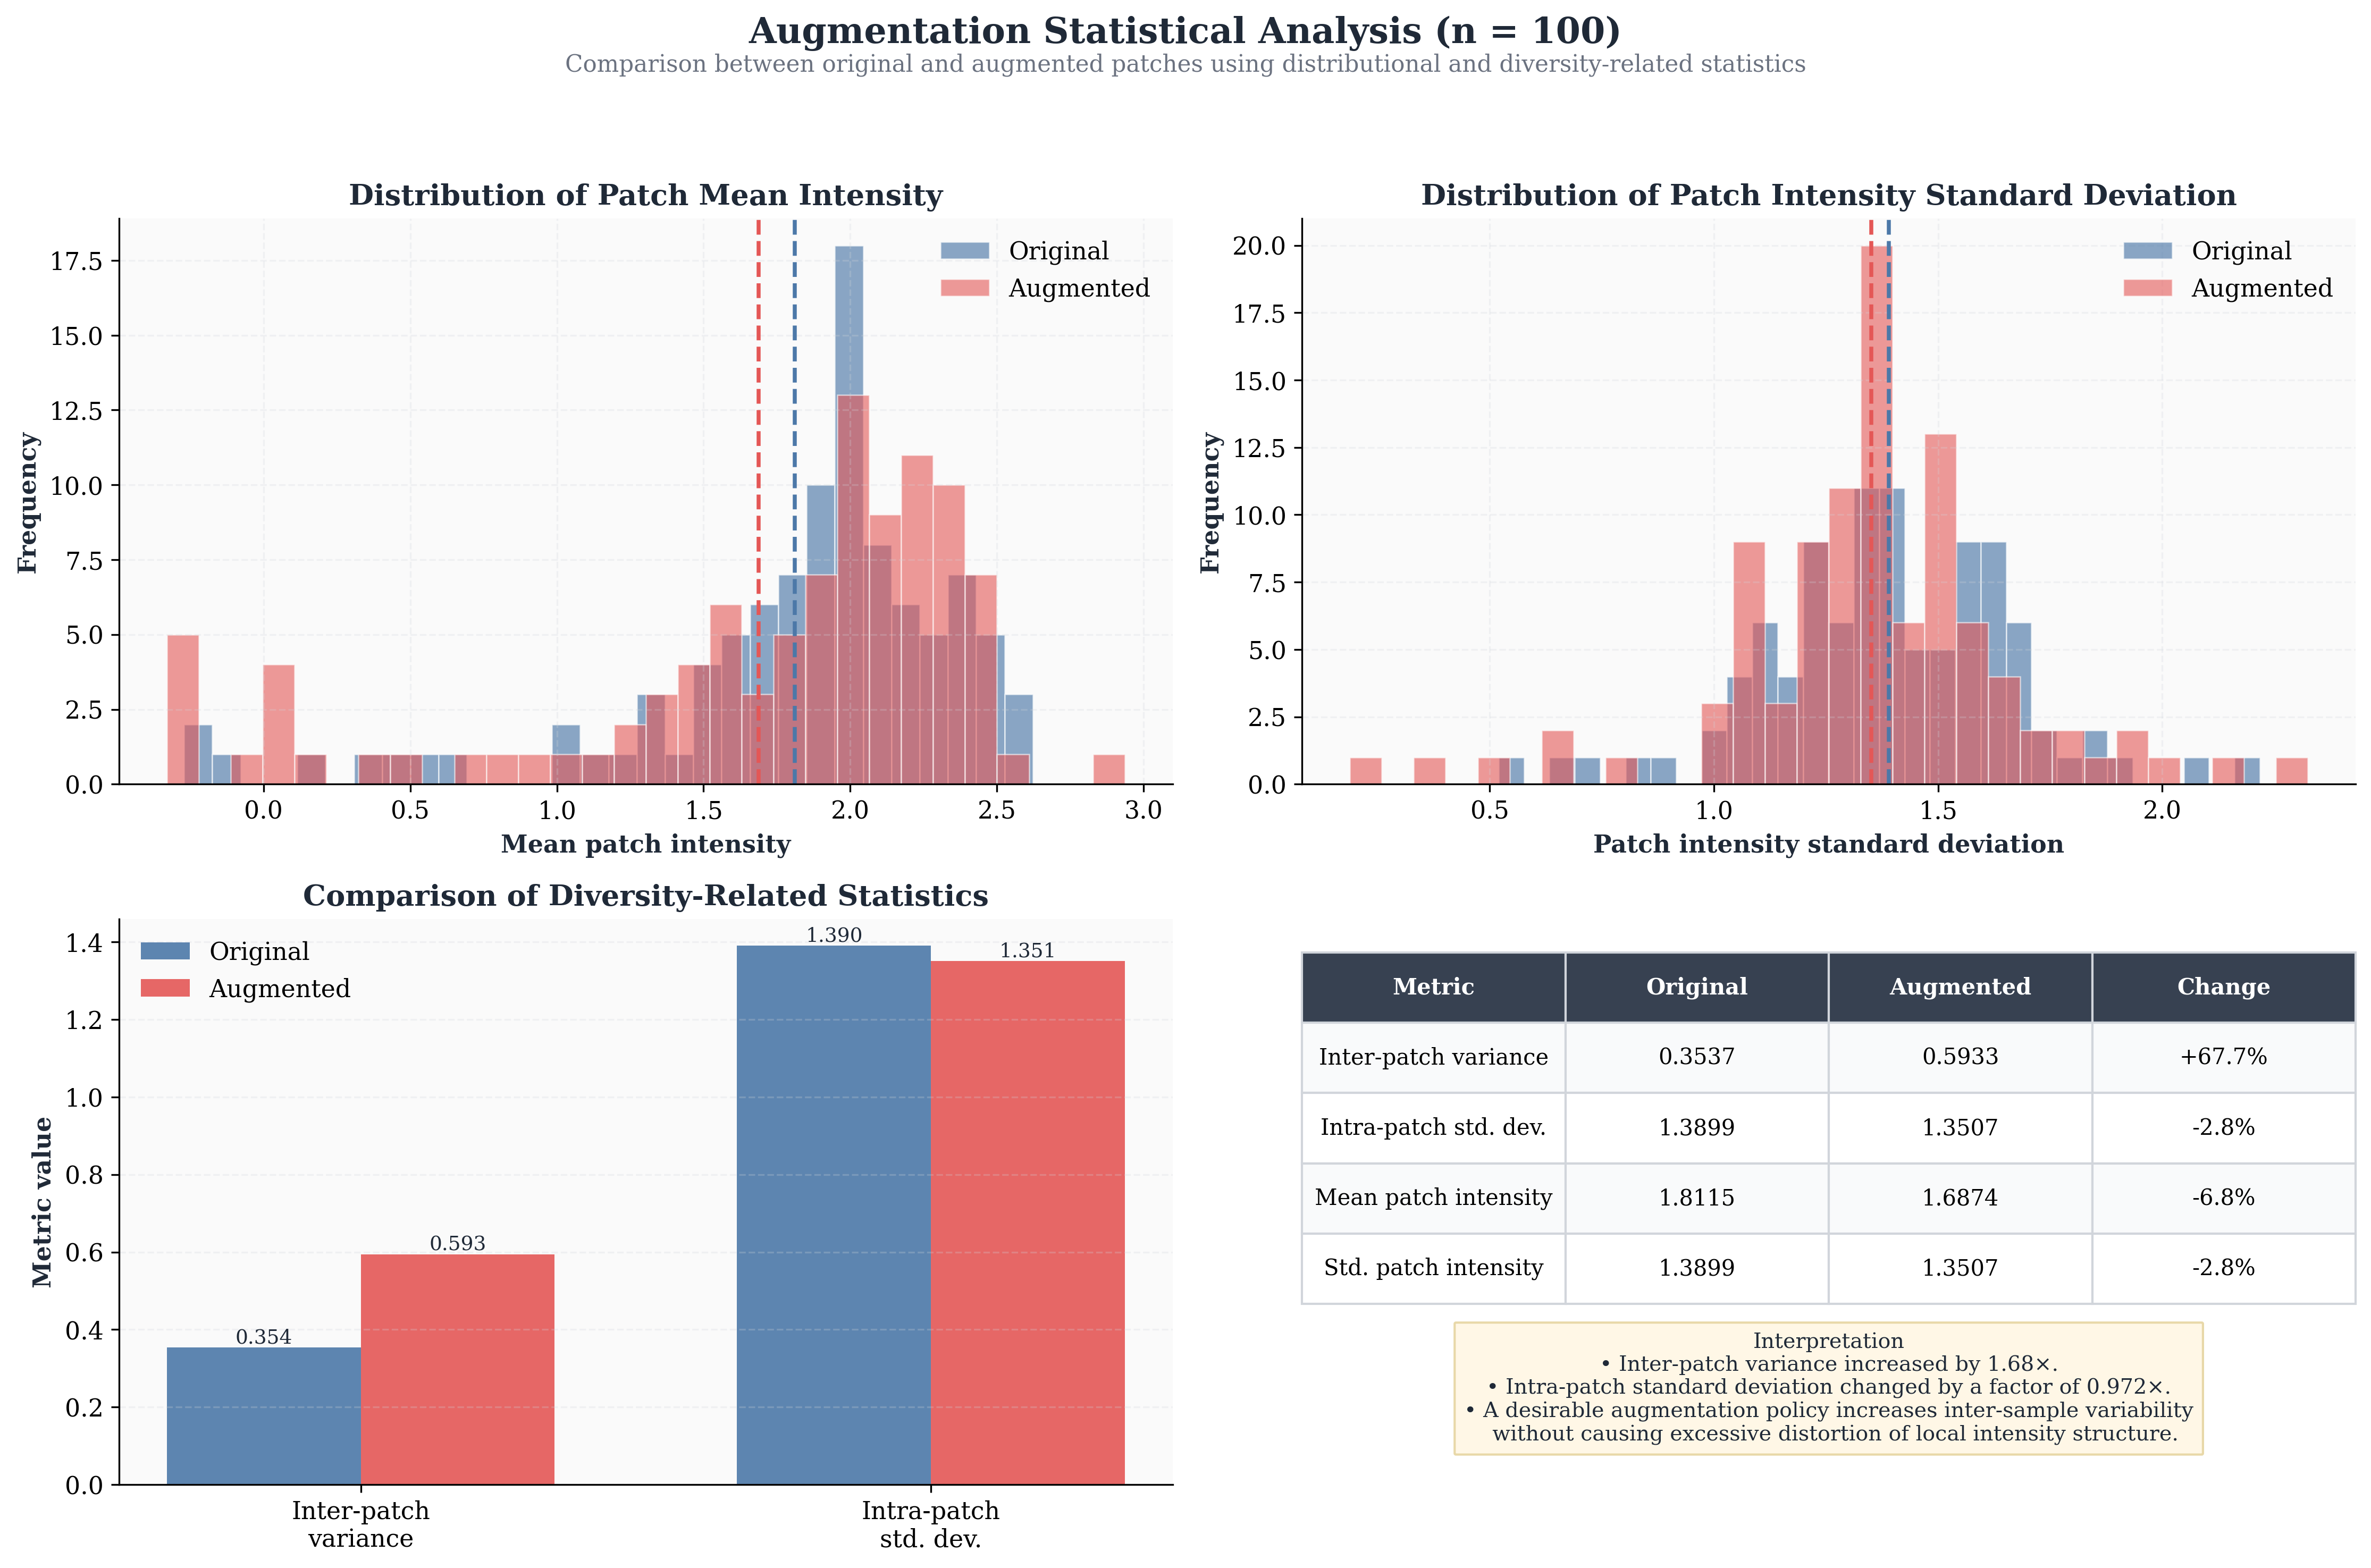

{'num_samples': 100, 'inter_var_orig': 0.35369984286620865, 'inter_var_aug': 0.5933126631767812, 'diversity_increase': 1.6774467819065702, 'intra_std_orig': 1.389925829768181, 'intra_std_aug': 1.3507499015331268, 'structure_ratio': 0.9718143749860465, 'mean_original': 1.8115123321115971, 'mean_augmented': 1.6874397265166043, 'std_original': 1.389925829768181, 'std_augmented': 1.3507499015331268, 'mean_ratio': np.float64(0.9315088264122569), 'std_ratio': np.float64(0.9718143749860465)}


In [67]:
fig, stats = plot_augmentation_statistics(
    generator=training_generator,
    num_samples=100,
    save_path="augmentation_statistics_2021.png"
)
plt.show()

print(stats)

In [ ]:
def analyze_and_visualize_dataset(
    training_generator,
    test_generator,
    training_loader,
    test_loader,
    num_samples=200,
    year=None,
    dataset_name="BraTS",
    class_names=None,
    class_colors=None,
    figsize=(13, 4.8),
    dpi=220,
    save_path=None
):
    print("Analyzing dataset distribution...")

    if class_names is None:
        class_names = ["Background", "Necrotic", "Edema", "Enhancing"]
    if class_colors is None:
        class_colors = ["#C9CED6", "#D95F5F", "#5AAE61", "#E6C84F"]

    num_classes = len(class_names)

    def to_numpy(x):
        if hasattr(x, "detach"):
            x = x.detach()
        if hasattr(x, "cpu"):
            x = x.cpu()
        if hasattr(x, "numpy"):
            return x.numpy()
        return np.asarray(x)

    def safe_pct(count, total):
        return (count / total * 100.0) if total > 0 else 0.0

    def get_num_patients(dataset):
        if hasattr(dataset, "list_IDs"):
            return len(dataset.list_IDs)
        if hasattr(dataset, "cases"):
            return len(dataset.cases)
        if hasattr(dataset, "case_ids"):
            return len(dataset.case_ids)
        return 0

    def extract_image_and_label(sample):
        image = None
        label = None

        if isinstance(sample, dict):
            for k in ["image", "images", "input", "x", "X"]:
                if k in sample:
                    image = sample[k]
                    break
            for k in ["mask", "seg", "label", "labels", "target", "y", "Y", "segmentation", "gt", "ground_truth"]:
                if k in sample:
                    label = sample[k]
                    break
            return image, label

        if isinstance(sample, (tuple, list)):
            if len(sample) >= 1:
                image = sample[0]
            if len(sample) >= 2:
                label = sample[1]
            return image, label

        return None, None

    def collect_stats(generator, n_samples, generator_name="generator"):
        class_counts = {i: 0 for i in range(num_classes)}
        tumor_ratios = []

        n_iter = min(n_samples, len(generator))
        label_available = None

        for i in range(n_iter):
            sample = generator[i]
            X, Y = extract_image_and_label(sample)

            if X is None:
                raise ValueError(f"Could not extract image from sample {i} in {generator_name}")

            if label_available is None:
                label_available = (Y is not None)

            if Y is not None:
                Y_np = to_numpy(Y)
                for cls in range(num_classes):
                    class_counts[cls] += int(np.sum(Y_np == cls))
                tumor_ratios.append(float(np.mean(Y_np > 0)) * 100.0)

        if label_available is None:
            label_available = False

        if label_available:
            total_voxels = sum(class_counts.values())
            class_pcts = [safe_pct(class_counts[i], total_voxels) for i in range(num_classes)]
            tumor_pct = float(np.sum(class_pcts[1:]))
        else:
            class_pcts = [np.nan] * num_classes
            tumor_pct = np.nan

        return {
            "label_available": label_available,
            "class_counts": class_counts,
            "class_pcts": class_pcts,
            "tumor_ratios": tumor_ratios,
            "tumor_pct": tumor_pct,
        }

    train_stats = collect_stats(training_generator, num_samples, "training_generator")
    test_stats = collect_stats(test_generator, num_samples, "test_generator")

    train_pcts = train_stats["class_pcts"]
    test_pcts = test_stats["class_pcts"]
    train_tumor_ratios = train_stats["tumor_ratios"]
    test_tumor_ratios = test_stats["tumor_ratios"]

    n_train_patients = get_num_patients(training_generator)
    n_test_patients = get_num_patients(test_generator)

    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11
    })

    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")

    # ========= Panel A: horizontal stacked composition =========
    ax = axes[0]
    y_positions = [1, 0]   # Train on top, Test below
    labels = ["Train", "Test"]
    all_pcts = [train_pcts, test_pcts]

    for row_idx, (y, pcts) in enumerate(zip(y_positions, all_pcts)):
        left = 0
        for j, (cls, color, val) in enumerate(zip(class_names, class_colors, pcts)):
            ax.barh(
                y, val, left=left, height=0.42,
                color=color, edgecolor="white", linewidth=1.0
            )
            if val >= 7:
                ax.text(left + val / 2, y, f"{val:.1f}%", ha="center", va="center",
                        fontsize=10, fontweight="bold", color="#1F2937")
            left += val

    ax.set_xlim(0, 100)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontweight="bold")
    ax.set_xlabel("Voxel composition (%)", fontweight="bold")
    ax.set_title("Class Composition", fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.22)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # legend compact phía dưới
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=c, ec="white")
        for c in class_colors
    ]
    ax.legend(
        handles, class_names,
        ncol=4, frameon=False,
        bbox_to_anchor=(0.0, -0.18), loc="upper left",
        columnspacing=1.2, handletextpad=0.5
    )

    # ========= Panel B: ECDF tumor ratio =========
    ax = axes[1]

    def ecdf(vals):
        vals = np.sort(np.asarray(vals, dtype=float))
        y = np.arange(1, len(vals) + 1) / len(vals)
        return vals, y

    x1, y1 = ecdf(train_tumor_ratios)
    x2, y2 = ecdf(test_tumor_ratios)

    ax.plot(x1, y1, linewidth=2.4, label=f"Train (n={len(x1)})")
    ax.plot(x2, y2, linewidth=2.4, label=f"Test (n={len(x2)})")

    train_mean = float(np.mean(train_tumor_ratios))
    test_mean = float(np.mean(test_tumor_ratios))
    train_med = float(np.median(train_tumor_ratios))
    test_med = float(np.median(test_tumor_ratios))

    ax.axvline(train_med, linestyle="--", linewidth=1.3, alpha=0.8)
    ax.axvline(test_med, linestyle="--", linewidth=1.3, alpha=0.8)

    ax.text(train_med, 0.08, f"train median {train_med:.1f}%", fontsize=9, ha="left")
    ax.text(test_med, 0.18, f"test median {test_med:.1f}%", fontsize=9, ha="left")

    ax.set_xlabel("Tumor ratio per sample (%)", fontweight="bold")
    ax.set_ylabel("Cumulative proportion", fontweight="bold")
    ax.set_title("Tumor Ratio Distribution", fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.22)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, loc="lower right")

    year_text = f" {year}" if year is not None else ""
    fig.suptitle(
        f"{dataset_name}{year_text}: dataset composition and tumor coverage",
        fontsize=16, fontweight="bold", y=1.02
    )

    # footnote nhỏ thay cho table/note box
    foot = (
        f"Train: {n_train_patients} items | "
        f"Test: {n_test_patients} items | "
        f"Mean tumor ratio: {train_mean:.1f}% vs {test_mean:.1f}%"
    )
    fig.text(0.5, -0.02, foot, ha="center", fontsize=10, color="#4B5563")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")

    stats = {
        "train_class_pcts": train_pcts,
        "test_class_pcts": test_pcts,
        "train_tumor_ratios": train_tumor_ratios,
        "test_tumor_ratios": test_tumor_ratios,
        "train_mean_tumor_ratio": train_mean,
        "test_mean_tumor_ratio": test_mean,
        "train_median_tumor_ratio": train_med,
        "test_median_tumor_ratio": test_med,
    }

    return fig, stats

In [34]:
train_cases, test_cases = split_cases(
    dataset_root=dataset_root,
    split_ratio=0.8,
    seed=42,
)
train_syn_dataset = BraTSDataset(
    dataset_root=dataset_root,
    cases=train_cases,
    augmentation=None,
    use_threshold=True,
    threshold_method="adaptive",
    spatial_size=(128, 128, 128),
    include_seg=True,
)

test_syn_dataset = BraTSDataset(
    dataset_root=dataset_root,
    cases=test_cases,
    augmentation=False,
    use_threshold=True,
    threshold_method="adaptive",
    spatial_size=(128, 128, 128),
    include_seg=True,
)
train_syn_loader = DataLoader(
    train_syn_dataset,
    batch_size=3,
    shuffle=True,
    num_workers=3,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
    prefetch_factor=1,
)
test_syn_loader = DataLoader(
    test_syn_dataset,
    batch_size=3,
    shuffle=False,
    num_workers=3,
    pin_memory=True,
    drop_last=False,
    persistent_workers=True,
    prefetch_factor=1,
)

Analyzing dataset distribution...


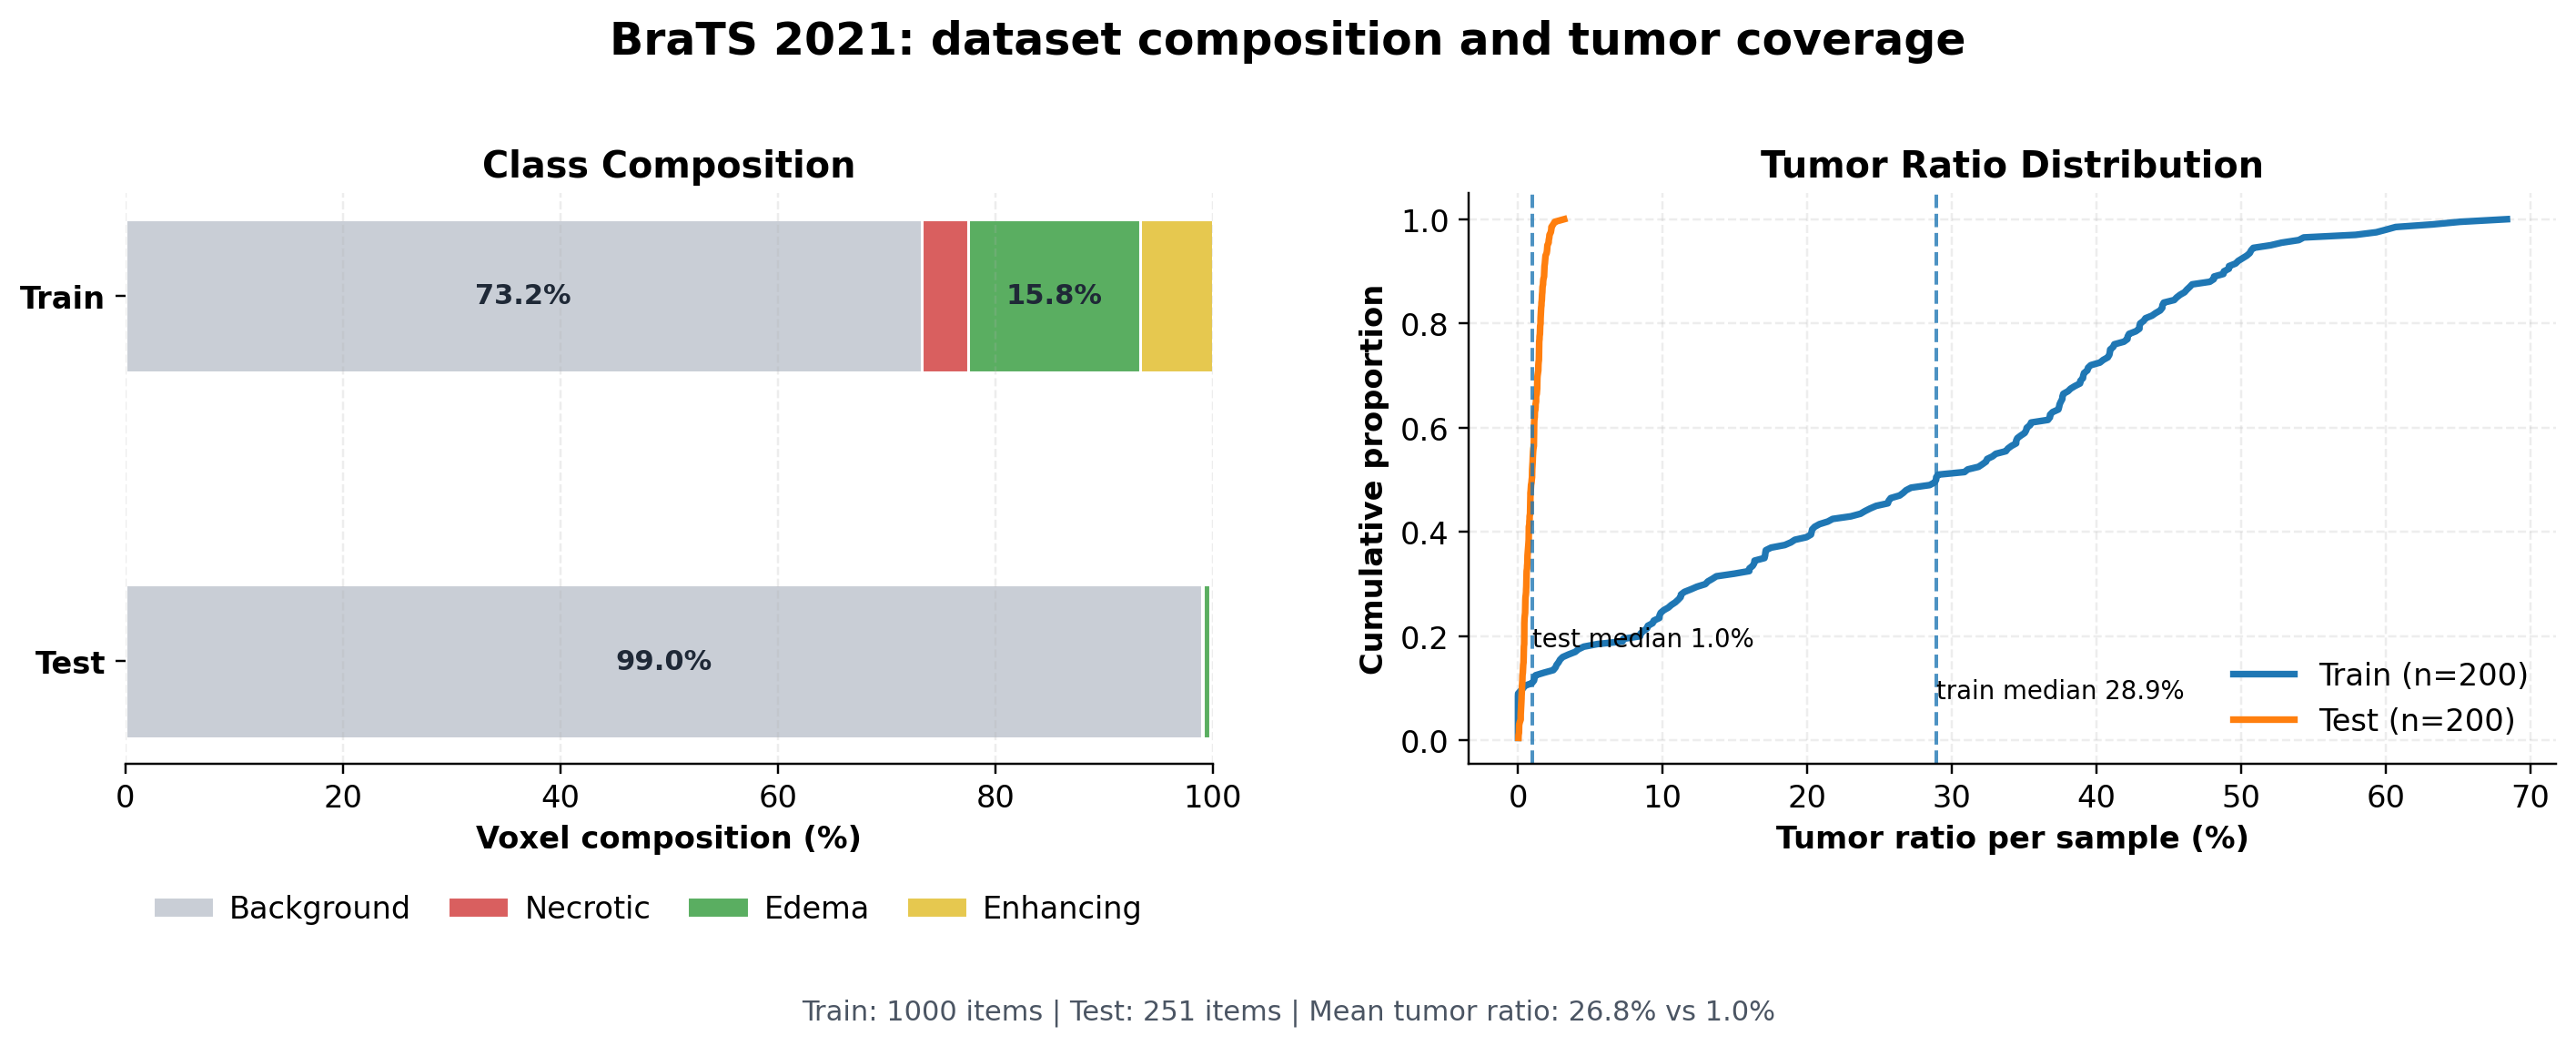

In [40]:
fig, stats = analyze_and_visualize_dataset(
    training_generator=training_generator,
    test_generator=test_dataset,
    training_loader=training_loader,
    test_loader=test_loader,
    num_samples=200,
    year=2021,
    dataset_name="BraTS",
    save_path="dataset_distribution_brats2021.png"
)
plt.show()

Analyzing dataset distribution...


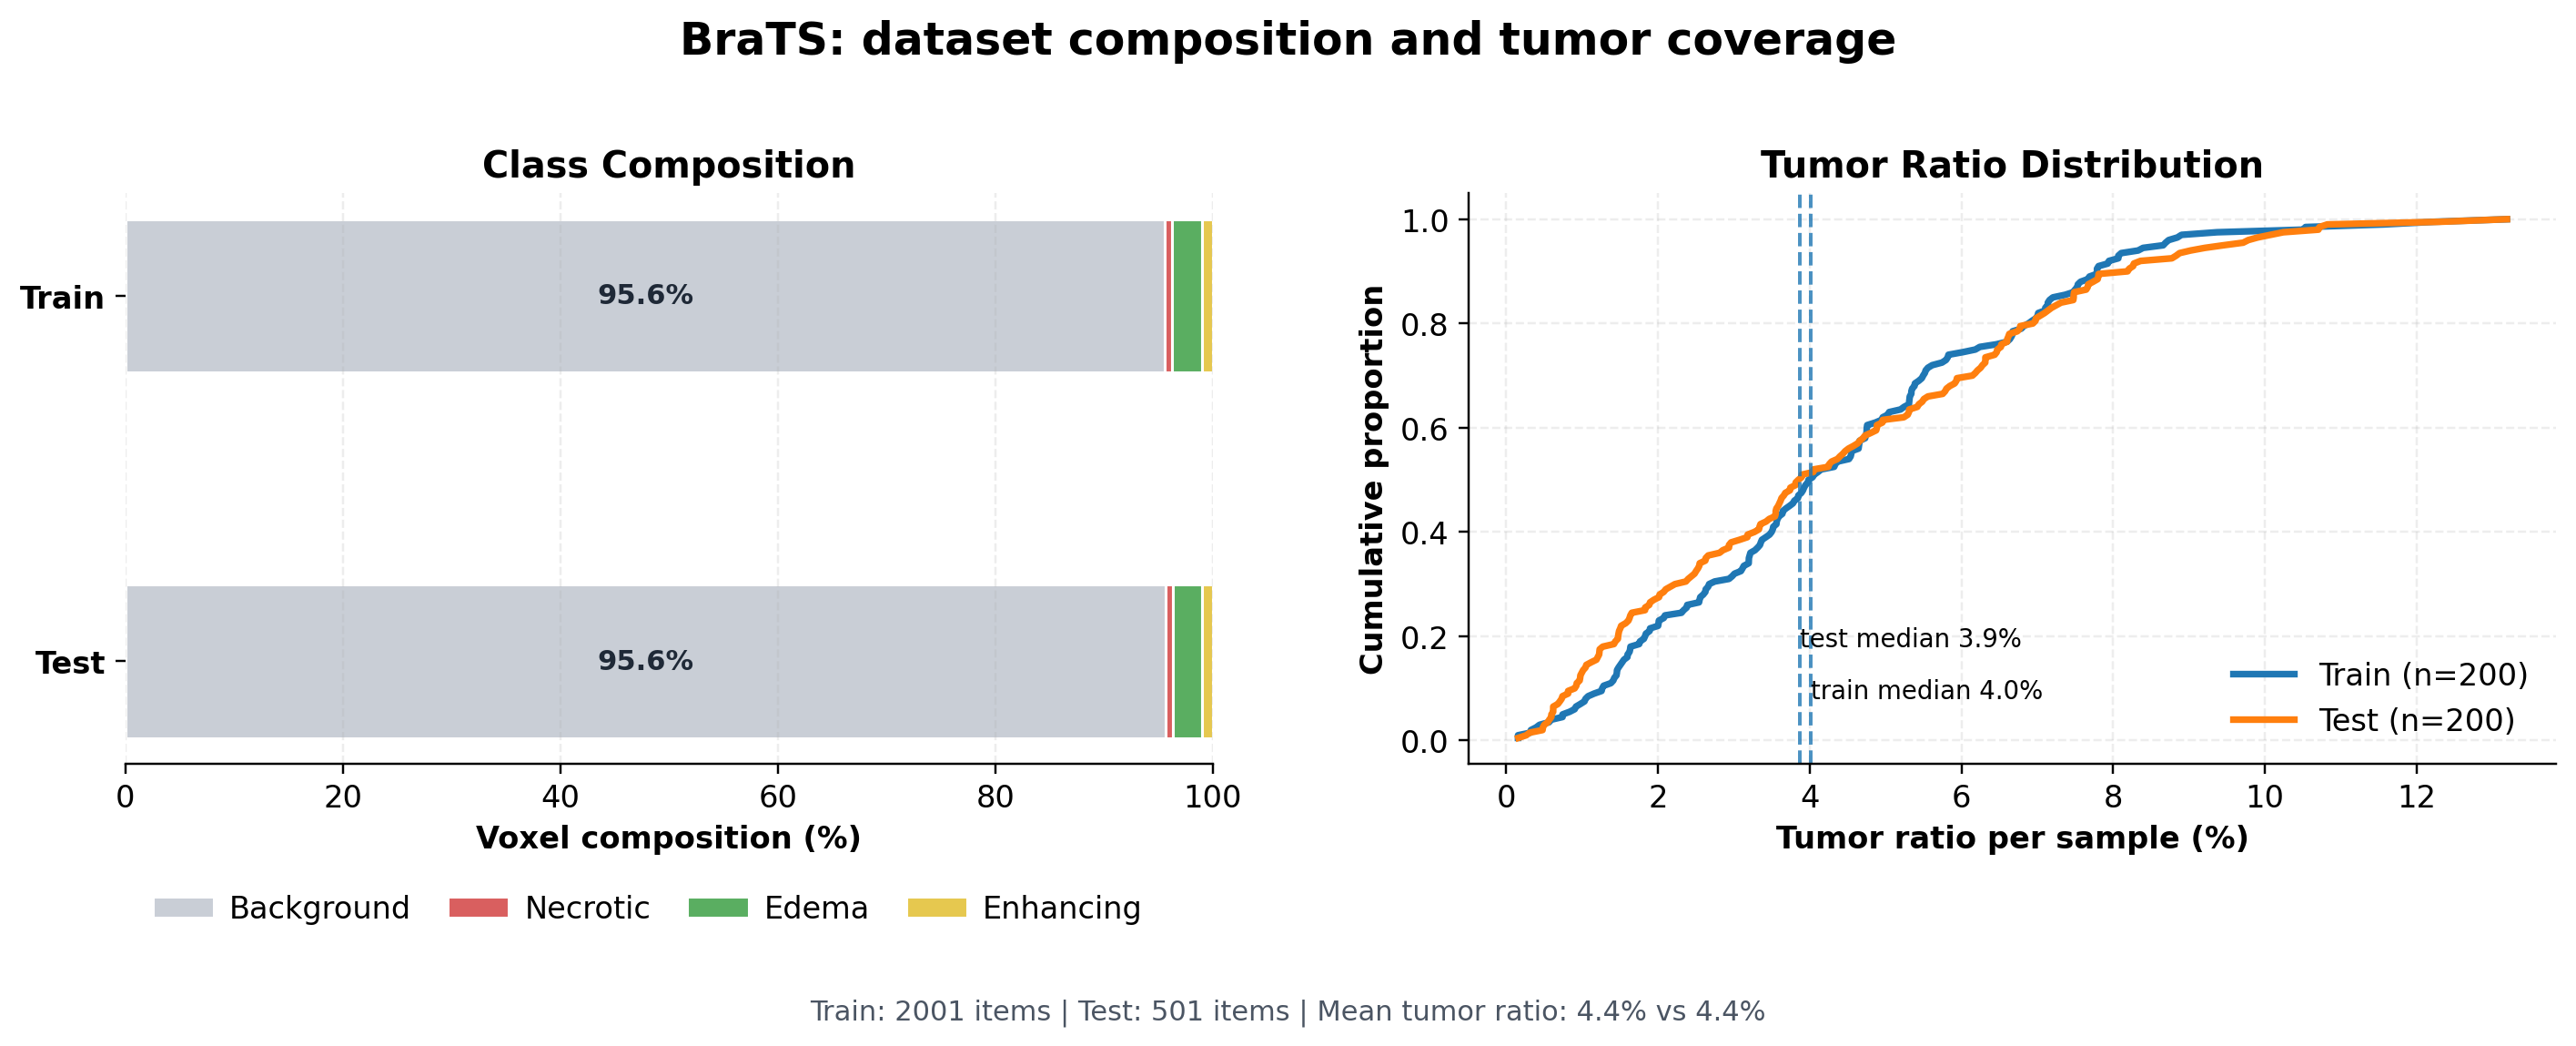

In [41]:
fig, stats = analyze_and_visualize_dataset(
    training_generator=train_syn_dataset,
    test_generator=test_syn_dataset,
    training_loader=train_syn_loader,
    test_loader=test_syn_loader,
    num_samples=200,
    year=None,
    dataset_name="BraTS",
    save_path="dataset_distribution_brats_synthesis.png"
)
plt.show()